# DASS-42 Mental Health Analysis

This project was initiated as a self-directed learning exercise to develop practical
Python skills for data analysis. Using a large open-access dataset (N=39,775) sourced
from Kaggle (original data: openpsychometrics.org), collected between 2017 and 2019,
I explored demographic and personality predictors of depression, anxiety, and stress
as measured by the DASS-42 (Lovibond & Lovibond, 1995).

The analysis was exploratory and no a priori hypotheses were formulated. Variables were
selected based on what the dataset offered and what seemed theoretically meaningful
from a psychological standpoint.

**Dataset:** Kaggle · openpsychometrics.org · N=39,775 · 2017-2019  
**Final sample after cleaning:** N=33,562 (6,213 removed, 15.6%)

In [1]:
# DASS-42 Mental Health Analysis
# Source: Kaggle (original data: openpsychometrics.org) | N=39,775 | 2017-2019
# Codebook: https://github.com/coeusanalytics/dass-42-analysis/blob/master/data/codebook.txt
# Author: Mathieu Nassour

In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr


In [3]:
# Loading dataset
df = pd.read_csv("DASS-42.csv", sep="\t")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 39,775 rows x 172 columns


In [4]:
# First look at all column names to understand dataset structure
print(df.columns.tolist())

['Q1A', 'Q1I', 'Q1E', 'Q2A', 'Q2I', 'Q2E', 'Q3A', 'Q3I', 'Q3E', 'Q4A', 'Q4I', 'Q4E', 'Q5A', 'Q5I', 'Q5E', 'Q6A', 'Q6I', 'Q6E', 'Q7A', 'Q7I', 'Q7E', 'Q8A', 'Q8I', 'Q8E', 'Q9A', 'Q9I', 'Q9E', 'Q10A', 'Q10I', 'Q10E', 'Q11A', 'Q11I', 'Q11E', 'Q12A', 'Q12I', 'Q12E', 'Q13A', 'Q13I', 'Q13E', 'Q14A', 'Q14I', 'Q14E', 'Q15A', 'Q15I', 'Q15E', 'Q16A', 'Q16I', 'Q16E', 'Q17A', 'Q17I', 'Q17E', 'Q18A', 'Q18I', 'Q18E', 'Q19A', 'Q19I', 'Q19E', 'Q20A', 'Q20I', 'Q20E', 'Q21A', 'Q21I', 'Q21E', 'Q22A', 'Q22I', 'Q22E', 'Q23A', 'Q23I', 'Q23E', 'Q24A', 'Q24I', 'Q24E', 'Q25A', 'Q25I', 'Q25E', 'Q26A', 'Q26I', 'Q26E', 'Q27A', 'Q27I', 'Q27E', 'Q28A', 'Q28I', 'Q28E', 'Q29A', 'Q29I', 'Q29E', 'Q30A', 'Q30I', 'Q30E', 'Q31A', 'Q31I', 'Q31E', 'Q32A', 'Q32I', 'Q32E', 'Q33A', 'Q33I', 'Q33E', 'Q34A', 'Q34I', 'Q34E', 'Q35A', 'Q35I', 'Q35E', 'Q36A', 'Q36I', 'Q36E', 'Q37A', 'Q37I', 'Q37E', 'Q38A', 'Q38I', 'Q38E', 'Q39A', 'Q39I', 'Q39E', 'Q40A', 'Q40I', 'Q40E', 'Q41A', 'Q41I', 'Q41E', 'Q42A', 'Q42I', 'Q42E', 'country', 'source

In [5]:
# Checking column types
df.dtypes.value_counts()

int64     170
object      2
Name: count, dtype: int64

In [6]:
# Identifying text columns
df.select_dtypes(include ='object').columns.tolist()

['country', 'major']

In [7]:
# Looking for missing values
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

major      11425
country        2
dtype: int64

In [8]:
# Demographic overview
for col in ['gender', 'education', 'urban', 'religion', 'orientation', 'race', 'voted', 'married', 'familysize',]:
    print(f"\n {col}")
    print(df[col].value_counts().sort_index())

# Age and country separated due to unique values
print("\n age")
print(df['age'].describe())

print("\n country")
print(df['country'].value_counts().head(25))


 gender
gender
0       67
1     8789
2    30367
3      552
Name: count, dtype: int64

 education
education
0      515
1     4066
2    15066
3    15120
4     5008
Name: count, dtype: int64

 urban
urban
0      382
1     8318
2    13232
3    17843
Name: count, dtype: int64

 religion
religion
0       356
1      3245
2      3845
3       527
4      3097
5       122
6      1544
7      2254
8       700
9       144
10    22073
11       64
12     1804
Name: count, dtype: int64

 orientation
orientation
0     3109
1    24269
2     5006
3     1955
4     1976
5     3460
Name: count, dtype: int64

 race
race
10    23106
20      333
30      603
40       22
50      220
60    10659
70     4832
Name: count, dtype: int64

 voted
voted
0      327
1    11048
2    28400
Name: count, dtype: int64

 married
married
0      195
1    34131
2     4357
3     1092
Name: count, dtype: int64

 familysize
familysize
0      1125
1      2946
2      9018
3      9206
4      7539
5      4830
6      2450
7      1243
8   

In [9]:
# Validating DASS items (everything looks good)
dass_items = [f"Q{i}A" for i in range(1, 43)]

invalid_dass = (df[dass_items] < 1) | (df[dass_items] > 4)
print(f"\nTotal invalid responses: {invalid_dass.sum().sum()}")


Total invalid responses: 0


In [10]:
# Computing DASS subscale scores
depression_items = [f"Q{i}A" for i in [3,5,10,13,16,17,21,24,26,31,34,37,38,42]]
anxiety_items = [f"Q{i}A" for i in [2,4,7,9,15,19,20,23,25,28,30,36,40,41]]
stress_items = [f"Q{i}A" for i in [1,6,8,11,12,14,18,22,27,29,32,33,35,39]]

df['depression'] = df[depression_items].sum(axis=1) - 14
df['anxiety'] = df[anxiety_items].sum(axis=1) - 14
df['stress'] = df[stress_items].sum(axis=1) - 14

print(df[['depression', 'anxiety', 'stress']].describe())

         depression       anxiety        stress
count  39775.000000  39775.000000  39775.000000
mean      21.060088     16.054758     21.153891
std       12.321566     10.249169     10.523291
min        0.000000      0.000000      0.000000
25%       11.000000      8.000000     13.000000
50%       21.000000     15.000000     21.000000
75%       32.000000     23.000000     29.000000
max       42.000000     42.000000     42.000000


In [11]:
# Flagging invalid demographic rows (orientation excluded - ~3k missing, kept as flag)
invalid_rows = (
    (df['gender'] ==0) |
    (df['education'] ==0) |
    (df['urban'] == 0) |
    (df['hand'] ==0) |
    (df['religion'] ==0) |
    (df['voted'] ==0) |
    (df['married'] ==0) |
    (df['engnat'] ==0) 
)

print(f"Rows flagged as invalid: {invalid_rows.sum()}")
print(f"Rows remaining after cleaning: {len(df) - invalid_rows.sum()}")

Rows flagged as invalid: 1862
Rows remaining after cleaning: 37913


In [12]:
# Removing invalid rows flagged above
df_clean = df[~invalid_rows].copy()

print(f"Original dataset: {len(df):,} rows")
print(f"After cleaning invalid codes: {len(df_clean):,} rows")
print(f"Removed: {len(df) - len(df_clean):,} rows ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

Original dataset: 39,775 rows
After cleaning invalid codes: 37,913 rows
Removed: 1,862 rows (4.68%)


##### 

In [13]:
# Inspecting age distribution
print (df_clean['age'].describe())
print(f"\nRows with age over 100: {(df_clean['age'] > 90).sum()}")
print(f"Rows with age under 12: {(df_clean['age'] < 13).sum()}")

count    37913.000000
mean        23.606441
std         21.986599
min         13.000000
25%         18.000000
50%         21.000000
75%         25.000000
max       1998.000000
Name: age, dtype: float64

Rows with age over 100: 8
Rows with age under 12: 0


In [14]:
# Removing implausible ages
df_clean = df_clean[df_clean['age'] <= 90].copy()

print(f"After age cleaning: {len(df_clean):,} rows")
print (f"Total removed so far: {39775 - len(df_clean):,} rows")

After age cleaning: 37,905 rows
Total removed so far: 1,870 rows


In [15]:
# Inspecting testelapse distribution 
print (df_clean['testelapse'].describe())
print(f"\nRows under 60 seconds: {(df_clean['testelapse'] < 60).sum()}")
print(f"Rows under 120 seconds: {(df_clean['testelapse'] < 120).sum()}")
print(f"Rows under 180 seconds: {(df_clean['testelapse'] < 180).sum()}")

count    3.790500e+04
mean     2.695826e+03
std      1.508676e+05
min      1.200000e+01
25%      1.650000e+02
50%      2.130000e+02
75%      2.950000e+02
max      2.082972e+07
Name: testelapse, dtype: float64

Rows under 60 seconds: 113
Rows under 120 seconds: 2253
Rows under 180 seconds: 12472


In [16]:
# Removing participants who completed DASS in under 120 seconds (~2.0s per items)
df_clean = df_clean[df_clean['testelapse'] >= 120].copy()

print(f"After rush filtering: {len(df_clean):,} rows")
print(f"Total removed so far: {39775 - len(df_clean):,} rows")

After rush filtering: 35,652 rows
Total removed so far: 4,123 rows


In [17]:
# Checking how many participants checked at least one fake word
fake_words = (df_clean['VCL6'] == 1) | (df_clean['VCL9'] == 1) | (df_clean['VCL12'] == 1)
print(f"Participants who checked at least one fake word; {fake_words.sum()}")
print(f"Percentage: {fake_words.sum()/len(df_clean)*100:.2f}%")

Participants who checked at least one fake word; 4390
Percentage: 12.31%


In [18]:
# Flag 1: inattentive responders (checked fake words)
# VCL6 (cuivocal), VCL9 (florted), VCL12 (verdid) are fake words
# Flag 2: Orientation not reported (code 0)
df_clean['inattentive'] = (
    (df_clean['VCL6'] == 1) |
    (df_clean['VCL9'] == 1) |
    (df_clean['VCL12'] == 1)
).astype(int)


df_clean['orientation_missing'] = (df_clean['orientation']== 0).astype(int)

print(f"Inattentive flag: {df_clean['inattentive'].sum():,} participants({df_clean['inattentive'].mean()*100:.2f}%)")
print(f"orientation_missing: {df_clean['orientation_missing'].sum():,} participants ({df_clean['orientation_missing'].mean()*100:.2f}%)")

Inattentive flag: 4,390 participants(12.31%)
orientation_missing: 2,641 participants (7.41%)


In [19]:
# Removing implausible familysize values

invalid_family = (df_clean['familysize'] == 0) | (df_clean['familysize'] > 15)
print (f"Rows to remove: {invalid_family.sum()}")

df_clean = df_clean[~invalid_family].copy()

print(f"After familysize cleaning: {len(df_clean):,} rows")
print(f"Total removed so far: {39775 - len(df_clean):,} rows")

Rows to remove: 945
After familysize cleaning: 34,707 rows
Total removed so far: 5,068 rows


In [20]:
# Checking for invalid 0s in TIPI items

tipi_cols =  [f"TIPI{i}" for i in range (1,11)]
print("Invalid 0s per TIPI items:")
print((df_clean[tipi_cols] == 0).sum())
print(f"\nRows with at least one TIPI 0: {(df_clean[tipi_cols] == 0).any(axis=1).sum()}")

Invalid 0s per TIPI items:
TIPI1     365
TIPI2     430
TIPI3     453
TIPI4     353
TIPI5     387
TIPI6     369
TIPI7     453
TIPI8     514
TIPI9     314
TIPI10    416
dtype: int64

Rows with at least one TIPI 0: 1145


In [21]:
# Removing rows with invalid TIPI responses

invalid_tipi = (df_clean[tipi_cols] == 0).any(axis=1)

df_clean = df_clean[~invalid_tipi].copy()

print(f"After TIPI cleaning; {len(df_clean):,} rows")
print(f"Total removed so far: {39775 - len(df_clean):,} rows")

After TIPI cleaning; 33,562 rows
Total removed so far: 6,213 rows


In [22]:
# Reversing negatively keyed TIPI items and computing Big Five scores

df_clean['TIPI2r'] = 8 - df_clean['TIPI2']
df_clean['TIPI4r'] = 8 - df_clean['TIPI4']
df_clean['TIPI6r'] = 8 - df_clean['TIPI6']
df_clean['TIPI8r'] = 8 - df_clean['TIPI8']
df_clean['TIPI10r'] = 8 - df_clean['TIPI10']

df_clean['extraversion'] = (df_clean['TIPI1'] + df_clean['TIPI6r']) / 2
df_clean['agreeableness'] = (df_clean['TIPI7'] + df_clean['TIPI2r']) / 2
df_clean['conscientiousness'] = (df_clean['TIPI3']  + df_clean['TIPI8r']) / 2
df_clean['emotional_stability'] = (df_clean['TIPI9']  + df_clean['TIPI4r']) / 2
df_clean['openness'] = (df_clean['TIPI5']  + df_clean['TIPI10r']) / 2

N = len(df_clean)  # final cleaned sample size

print(df_clean[['extraversion', 'agreeableness', 'conscientiousness', 'emotional_stability', 'openness']].describe())


       extraversion  agreeableness  conscientiousness  emotional_stability  \
count  33562.000000   33562.000000       33562.000000         33562.000000   
mean       3.475776       4.561811           4.248719             3.254529   
std        1.546184       1.205724           1.473210             1.510690   
min        1.000000       1.000000           1.000000             1.000000   
25%        2.000000       4.000000           3.500000             2.000000   
50%        3.500000       4.500000           4.000000             3.000000   
75%        4.500000       5.500000           5.500000             4.000000   
max        7.000000       7.000000           7.000000             7.000000   

           openness  
count  33562.000000  
mean       4.619555  
std        1.325551  
min        1.000000  
25%        4.000000  
50%        4.500000  
75%        5.500000  
max        7.000000  


## Data Cleaning

Six exclusion criteria were applied sequentially (invalid demographic codes, implausible
ages, rush completions <120s, implausible family size, invalid TIPI responses), removing
6,213 rows (15.6%), leaving N=33,562. Two flags were created rather than excluded:
inattentive responders and orientation not reported, addressed in dedicated analyses.

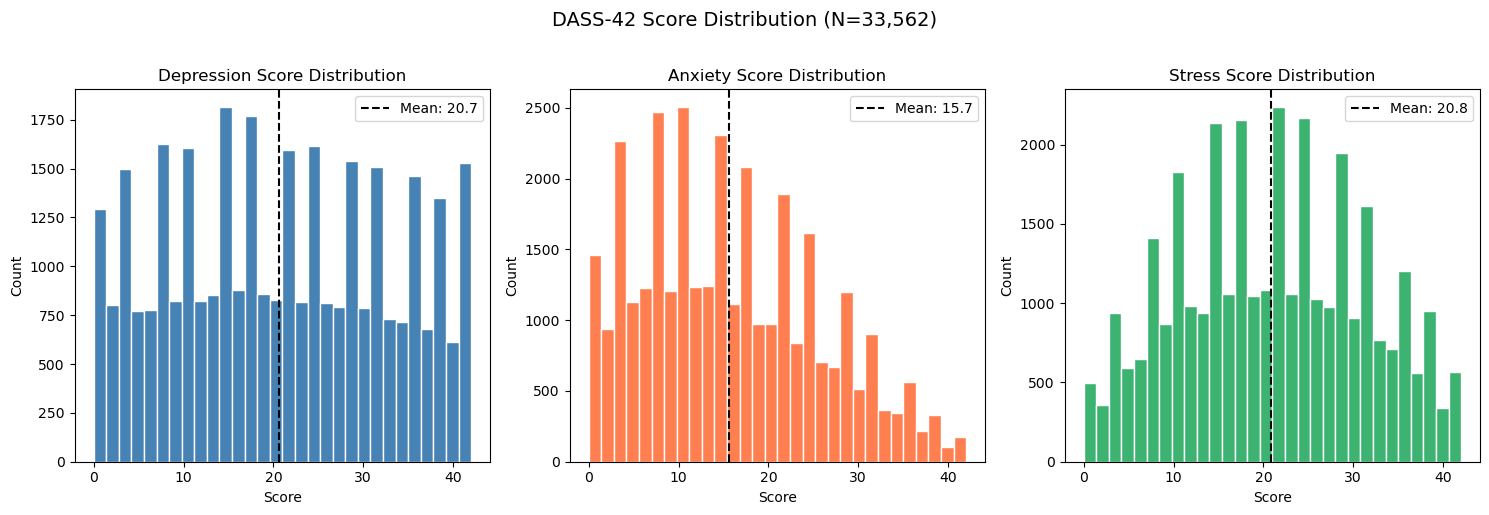

In [23]:
# Distribution of DASS subscale scores
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip (axes,
                           ['depression', 'anxiety', 'stress'],
                           ['steelblue', 'coral', 'mediumseagreen']):
    ax.hist(df_clean[col], bins = 30, color=color, edgecolor='white')
    ax.set_title (f'{col.capitalize()} Score Distribution')
    ax.set_xlabel ('Score')
    ax.set_ylabel ('Count')
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df_clean[col].mean():.1f}')
    ax.legend()

plt.suptitle('DASS-42 Score Distribution (N=33,562)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Check religion distribution by race
religion_map = {1:'Agnostic', 2:'Atheist', 3:'Buddhist', 4:'Catholic',
                5:'Mormon', 6:'Protestant', 7:'Christian Other', 
                8:'Hindu', 9:'Jewish', 10:'Muslim', 11:'Sikh', 12:'Other'}

race_map = {10:'Asian', 20:'Arab', 30:'Black', 40:'Indigenous', 
            50:'Native American', 60:'White', 70:'Other'}

df_clean['religion_label'] = df_clean['religion'].map(religion_map)
df_clean['race_label'] = df_clean['race'].map(race_map)

pd.crosstab(df_clean['race_label'],
            df_clean['religion_label'],
            normalize='index').round(2)

religion_label,Agnostic,Atheist,Buddhist,Catholic,Christian Other,Hindu,Jewish,Mormon,Muslim,Other,Protestant,Sikh
race_label,,,,,,,,,,,,
Arab,0.05,0.10,0.00,0.01,0.04,0.00,0.00,0.00,0.77,0.02,0.01,0.0
Asian,0.02,0.02,0.02,0.05,0.01,0.02,0.00,0.00,0.83,0.01,0.02,0.0
Black,0.14,0.07,0.01,0.11,0.35,0.01,0.00,0.00,0.04,0.14,0.13,0.0
Indigenous,0.06,0.06,0.06,0.19,0.12,0.00,0.00,0.00,0.25,0.12,0.12,0.0
Native American,0.16,0.15,0.01,0.22,0.15,0.01,0.01,0.02,0.02,0.20,0.06,0.0
Other,0.08,0.08,0.01,0.09,0.05,0.02,0.00,0.00,0.58,0.06,0.02,0.0
White,0.22,0.28,0.01,0.12,0.14,0.00,0.01,0.01,0.01,0.11,0.09,0.0


In [25]:
# Checking DASS scores across Christian subgroups before deciding to merge
christians = df_clean['religion'].isin([4, 5, 6, 7])
df_clean[christians].groupby('religion')[['depression', 'anxiety', 'stress']].agg(['mean', 'count'])

depression          anxiety           stress      
               mean count       mean count       mean count
religion                                                   
4         20.768167  2532  15.553712  2532  21.339652  2532
5         21.938776    98  15.938776    98  22.510204    98
6         19.355162  1298  13.043914  1298  19.175655  1298
7         20.404584  1876  15.010661  1876  21.399254  1876

In [26]:
# Merging all Christian subgroups into one 
religion_map_clean = {
    1: 'Agnostic',
    2: 'Atheist', 
    3: 'Buddhist',
    4: 'Christian',
    5: 'Christian', 
    6: 'Christian',  
    7: 'Christian',  
    8: 'Hindu',
    9: 'Jewish',
    10: 'Muslim',
    11: 'Sikh',
    12: 'Other'
}

df_clean['religion_label'] = df_clean['religion'].map(religion_map_clean)

print(df_clean['religion_label'].value_counts())

religion_label
Muslim       19259
Christian     5804
Atheist       3145
Agnostic      2704
Other         1480
Hindu          569
Buddhist       438
Jewish         105
Sikh            58
Name: count, dtype: int64


In [27]:
valid_religions = ['Muslim', 'Christian', 'Atheist', 
                   'Agnostic', 'Other']
df_religion = df_clean[df_clean['religion_label'].isin(valid_religions)].copy()
print(df_religion['religion_label'].value_counts())

religion_label
Muslim       19259
Christian     5804
Atheist       3145
Agnostic      2704
Other         1480
Name: count, dtype: int64


Catholic, Mormon, Protestant, and Christian Other subgroups were merged into a single
'Christian' category after confirming comparable score profiles across subgroups
(differences within 3 points across all subscales). Buddhist (n=438), Hindu (n=569),
Jewish (n=105), and Sikh (n=58) were excluded from religion-specific analyses due to
insufficient group sizes for reliable statistical comparisons.

In [28]:
# Creating region variable grouping countries culturally
southeast_asia = ['MY', 'ID', 'PH', 'SG', 'BN', 'IN']
western = ['US', 'GB', 'CA', 'AU', 'NZ', 'DE', 'FR', 'PL', 'IT', 'NL', 'ES', 'FI', 'RO']

def assign_region(country):
    if country in southeast_asia:
        return 'Southeast Asian'
    elif country in western:
        return 'Western'
    else:
        return 'Other'

df_clean['region'] = df_clean['country'].apply(assign_region)

print (df_clean['region'].value_counts())

region
Southeast Asian    20931
Western             9926
Other               2705
Name: count, dtype: int64


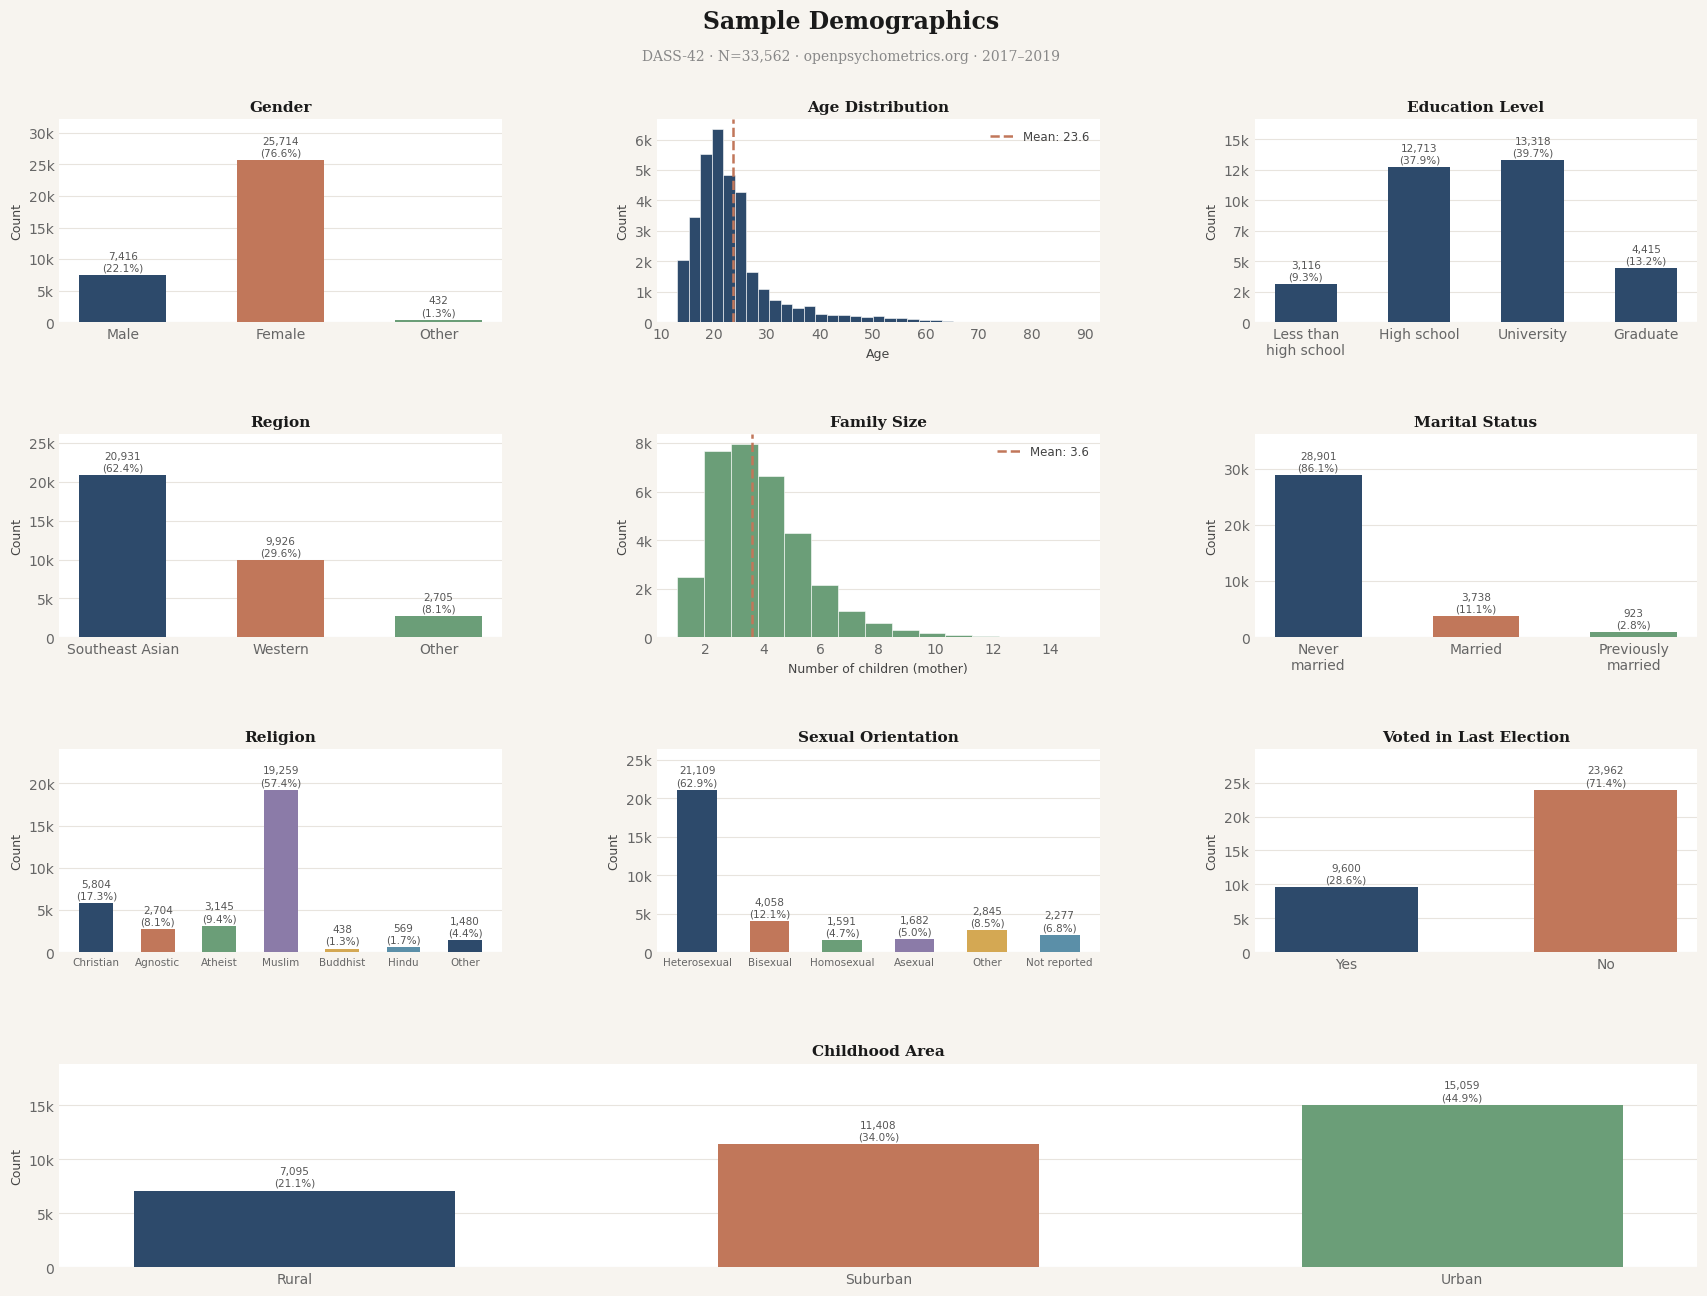

In [29]:
# Sample Demographics Visualization 
 
gender_map      = {1: 'Male', 2: 'Female', 3: 'Other'}
education_map   = {1: 'Less than\nhigh school', 2: 'High school', 3: 'University', 4: 'Graduate'}
urban_map       = {1: 'Rural', 2: 'Suburban', 3: 'Urban'}
marital_map     = {1: 'Never\nmarried', 2: 'Married', 3: 'Previously\nmarried'}
voted_map       = {1: 'Yes', 2: 'No'}
orientation_map = {0: 'Not reported', 1: 'Heterosexual', 2: 'Bisexual',
                   3: 'Homosexual', 4: 'Asexual', 5: 'Other'}

df_clean['gender_label']      = df_clean['gender'].map(gender_map)
df_clean['education_label']   = df_clean['education'].map(education_map)
df_clean['urban_label']       = df_clean['urban'].map(urban_map)
df_clean['marital_label']     = df_clean['married'].map(marital_map)
df_clean['voted_label']       = df_clean['voted'].map(voted_map)
df_clean['orientation_label'] = df_clean['orientation'].map(orientation_map)

# Style constants (heavy use of AI for better visuals)
BACKGROUND = '#F7F4EF'
PANEL_BG   = '#FFFFFF'
ACCENT     = '#2D4A6B'
MEAN_COLOR = '#C1775A'
COLORS_CAT = ['#2D4A6B', '#C1775A', '#6B9E78', '#8B7BA8', '#D4A853', '#5B8FA8']

FONT_TITLE = {'fontsize': 11, 'fontweight': 'bold',
              'color': '#1a1a1a', 'fontfamily': 'serif'}
FONT_ANNOT = {'fontsize': 7.5, 'color': '#555555'}
FONT_AXIS  = {'fontsize': 9, 'color': '#444444'}

def thousands(x, pos):
    return f'{int(x/1000)}k' if x >= 1000 else str(int(x))

formatter = FuncFormatter(thousands)

def style_axes(ax):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

def style_bar(ax, labels, values, colors):
    ax.bar(labels, values, color=colors, edgecolor='none', width=0.55, zorder=3)
    ax.set_ylim(0, max(values) * 1.25)

def annotate_bars(ax, values):
    y_max = ax.get_ylim()[1]
    offset = y_max * 0.012
    for i, v in enumerate(values):
        pct = v / N * 100
        ax.text(i, v + offset, f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', **FONT_ANNOT)

# Figure and grid 
fig = plt.figure(figsize=(18, 14), facecolor=BACKGROUND)
fig.subplots_adjust(hspace=0.55, wspace=0.35,
                    top=0.88, bottom=0.06,
                    left=0.06, right=0.97)
gs = gridspec.GridSpec(4, 3, figure=fig)

# Helper to create and style each subplot
def make_ax(row, col):
    ax = fig.add_subplot(gs[row, col])
    style_axes(ax)
    return ax

# Panel 1: Gender 
ax = make_ax(0, 0)
order  = ['Male', 'Female', 'Other']
counts = df_clean['gender_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[0], COLORS_CAT[1], COLORS_CAT[2]])
annotate_bars(ax, counts.values)
ax.set_title('Gender', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)

# Panel 2: Age 
ax = make_ax(0, 1)
ax.hist(df_clean['age'], bins=35, color=ACCENT,
        edgecolor='white', linewidth=0.4, zorder=3)
mean_age = df_clean['age'].mean()
ax.axvline(mean_age, color=MEAN_COLOR, linestyle='--',
           linewidth=1.8, label=f'Mean: {mean_age:.1f}', zorder=4)
ax.set_title('Age Distribution', **FONT_TITLE)
ax.set_xlabel('Age', **FONT_AXIS)
ax.set_ylabel('Count', **FONT_AXIS)
ax.legend(fontsize=8.5, frameon=False, labelcolor='#444444')
ax.yaxis.set_major_formatter(formatter)

# Panel 3: Education
ax = make_ax(0, 2)
order  = ['Less than\nhigh school', 'High school', 'University', 'Graduate']
counts = df_clean['education_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values, [COLORS_CAT[0]] * 4)
annotate_bars(ax, counts.values)
ax.set_title('Education Level', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)

# Panel 4: Region
ax = make_ax(1, 0)
order  = ['Southeast Asian', 'Western', 'Other']
counts = df_clean['region'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[0], COLORS_CAT[1], COLORS_CAT[2]])
annotate_bars(ax, counts.values)
ax.set_title('Region', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)

# Panel 5: Family size
ax = make_ax(1, 1)
ax.hist(df_clean['familysize'], bins=15, color=COLORS_CAT[2],
        edgecolor='white', linewidth=0.4, zorder=3)
mean_fam = df_clean['familysize'].mean()
ax.axvline(mean_fam, color=MEAN_COLOR, linestyle='--',
           linewidth=1.8, label=f'Mean: {mean_fam:.1f}', zorder=4)
ax.set_title('Family Size', **FONT_TITLE)
ax.set_xlabel('Number of children (mother)', **FONT_AXIS)
ax.set_ylabel('Count', **FONT_AXIS)
ax.legend(fontsize=8.5, frameon=False, labelcolor='#444444')
ax.yaxis.set_major_formatter(formatter)

# Panel 6: Marital status
ax = make_ax(1, 2)
order  = ['Never\nmarried', 'Married', 'Previously\nmarried']
counts = df_clean['marital_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[0], COLORS_CAT[1], COLORS_CAT[2]])
annotate_bars(ax, counts.values)
ax.set_title('Marital Status', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)

# Panel 7: Religion
ax = make_ax(2, 0)
order  = ['Christian', 'Agnostic', 'Atheist', 'Muslim',
          'Buddhist', 'Hindu', 'Other']
counts = df_clean['religion_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[i % len(COLORS_CAT)] for i in range(len(order))])
annotate_bars(ax, counts.values)
ax.set_title('Religion', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)
ax.tick_params(axis='x', labelsize=7.5)

# Panel 8: Orientation 
ax = make_ax(2, 1)
order  = ['Heterosexual', 'Bisexual', 'Homosexual',
          'Asexual', 'Other', 'Not reported']
counts = df_clean['orientation_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[i % len(COLORS_CAT)] for i in range(len(order))])
annotate_bars(ax, counts.values)
ax.set_title('Sexual Orientation', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)
ax.tick_params(axis='x', labelsize=7.5)

# Panel 9: Voted 
ax = make_ax(2, 2)
order  = ['Yes', 'No']
counts = df_clean['voted_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[0], COLORS_CAT[1]])
annotate_bars(ax, counts.values)
ax.set_title('Voted in Last Election', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)

# Panel 10: Urban/Rural
ax = fig.add_subplot(gs[3, :])
style_axes(ax)
order  = ['Rural', 'Suburban', 'Urban']
counts = df_clean['urban_label'].value_counts().reindex(order)
style_bar(ax, order, counts.values,
          [COLORS_CAT[0], COLORS_CAT[1], COLORS_CAT[2]])
annotate_bars(ax, counts.values)
ax.set_title('Childhood Area', **FONT_TITLE)
ax.set_ylabel('Count', **FONT_AXIS)

# Main title & subtitle 
fig.text(0.5, 0.945, 'Sample Demographics',
         ha='center', fontsize=17, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.922, f'DASS-42 · N={N:,} · openpsychometrics.org · 2017–2019',
         ha='center', fontsize=10, color='#888888', fontfamily='serif')

plt.show()


Depression
                      n     %
depression_cat               
Normal             7592  22.6
Mild               3282   9.8
Moderate           6151  18.3
Severe             5634  16.8
Extremely Severe  10903  32.5

Anxiety
                      n     %
anxiety_cat                  
Normal             8256  24.6
Mild               2443   7.3
Moderate           6172  18.4
Severe             5290  15.8
Extremely Severe  11401  34.0

Stress
                      n     %
stress_cat                   
Normal            10116  30.1
Mild               4290  12.8
Moderate           7587  22.6
Severe             7237  21.6
Extremely Severe   4332  12.9


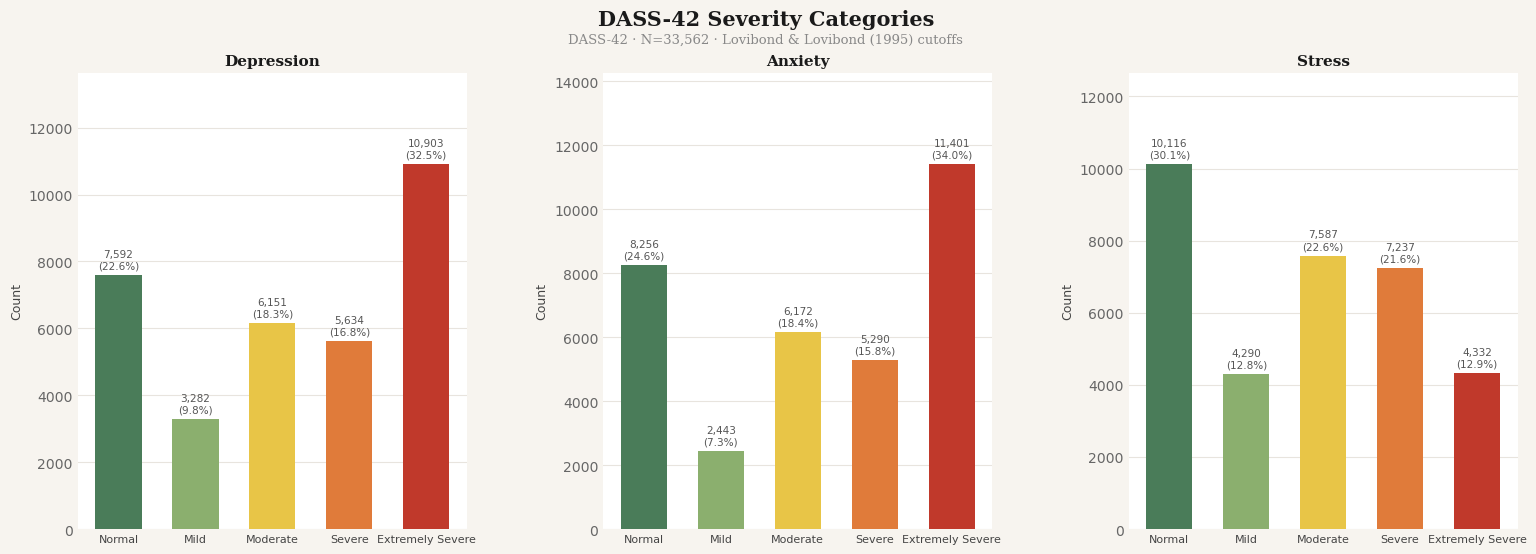

In [30]:
# Official DASS-42 cutoffs (Lovibond & Lovibond, 1995)
def classify_depression(score):
    if score <= 9: return 'Normal'
    elif score <= 13: return 'Mild'
    elif score <= 20: return 'Moderate'
    elif score <= 27: return 'Severe'
    else: return 'Extremely Severe'

def classify_anxiety(score):
    if score <= 7: return 'Normal'
    elif score <= 9:  return 'Mild'
    elif score <= 14: return 'Moderate'
    elif score <= 19: return 'Severe'
    else: return 'Extremely Severe'

def classify_stress(score):
    if score <= 14: return 'Normal'
    elif score <= 18: return 'Mild'
    elif score <= 25: return 'Moderate'
    elif score <= 33: return 'Severe'
    else: return 'Extremely Severe'

df_clean['depression_cat'] = df_clean['depression'].apply(classify_depression)
df_clean['anxiety_cat'] = df_clean['anxiety'].apply(classify_anxiety)
df_clean['stress_cat'] = df_clean['stress'].apply(classify_stress)

severity_order = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe']
 
for subscale, cat_col in [('Depression', 'depression_cat'),
                           ('Anxiety', 'anxiety_cat'),
                           ('Stress', 'stress_cat')]:
    print(f"\n{subscale}")
    counts = df_clean[cat_col].value_counts().reindex(severity_order)
    pcts = (counts / N * 100).round(1)
    summary = pd.DataFrame({'n': counts, '%': pcts})
    print(summary)

# Visualization
SEVERITY_COLORS = ['#4A7C59', '#8BAF6E', '#E8C547', '#E07B3A', '#C0392B']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, cat_col, title in zip(axes,
                               ['depression_cat', 'anxiety_cat', 'stress_cat'],
                               ['Depression',     'Anxiety',     'Stress']):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    counts = df_clean[cat_col].value_counts().reindex(severity_order)

    bars = ax.bar(severity_order, counts.values,
                  color=SEVERITY_COLORS, edgecolor='none',
                  width=0.6, zorder=3)

    ax.set_ylim(0, max(counts.values) * 1.25)
    for i, v in enumerate(counts.values):
        pct = v / N * 100
        ax.text(i, v + max(counts.values) * 0.012,
                f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom',
                fontsize=7.5, color='#555555')

    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Count', fontsize=9, color='#444444')
    ax.set_xticks(range(len(severity_order)))
    ax.set_xticklabels(severity_order, fontsize=8, color='#444444')

fig.text(0.5, 0.96, 'DASS-42 Severity Categories',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · Lovibond & Lovibond (1995) cutoffs',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

In [31]:
# Mean DASS scores by key demographic groups

# Groups to summarize: gender, region, education, marital status
group_vars = {
    'Gender':         'gender_label',
    'Region':         'region',
    'Education':      'education_label',
    'Marital Status': 'marital_label'
}

for group_name, col in group_vars.items():
    print(f"\n{'─'*45}")
    print(f"{group_name}")
    print(f"{'─'*45}")
    summary = (df_clean
               .groupby(col)[['depression', 'anxiety', 'stress']]
               .agg(['mean', 'std'])
               .round(2))
    print(summary)


─────────────────────────────────────────────
Gender
─────────────────────────────────────────────
             depression        anxiety        stress       
                   mean    std    mean    std   mean    std
gender_label                                               
Female            20.72  11.97   16.32   9.85  21.45  10.15
Male              20.07  12.30   13.11   9.38  18.41  10.21
Other             26.29  11.21   19.84  10.28  24.49   9.55

─────────────────────────────────────────────
Region
─────────────────────────────────────────────
                depression        anxiety        stress       
                      mean    std    mean    std   mean    std
region                                                        
Other                21.93  12.27   14.89  10.04  20.65  10.25
Southeast Asian      20.03  11.87   16.16   9.71  20.67  10.21
Western              21.60  12.30   14.80  10.04  21.17  10.31

─────────────────────────────────────────────
Education
─────

Big Five Personality Traits — Descriptive Statistics
───────────────────────────────────────────────────────
                     mean   std  min  max
extraversion         3.48  1.55  1.0  7.0
agreeableness        4.56  1.21  1.0  7.0
conscientiousness    4.25  1.47  1.0  7.0
emotional_stability  3.25  1.51  1.0  7.0
openness             4.62  1.33  1.0  7.0


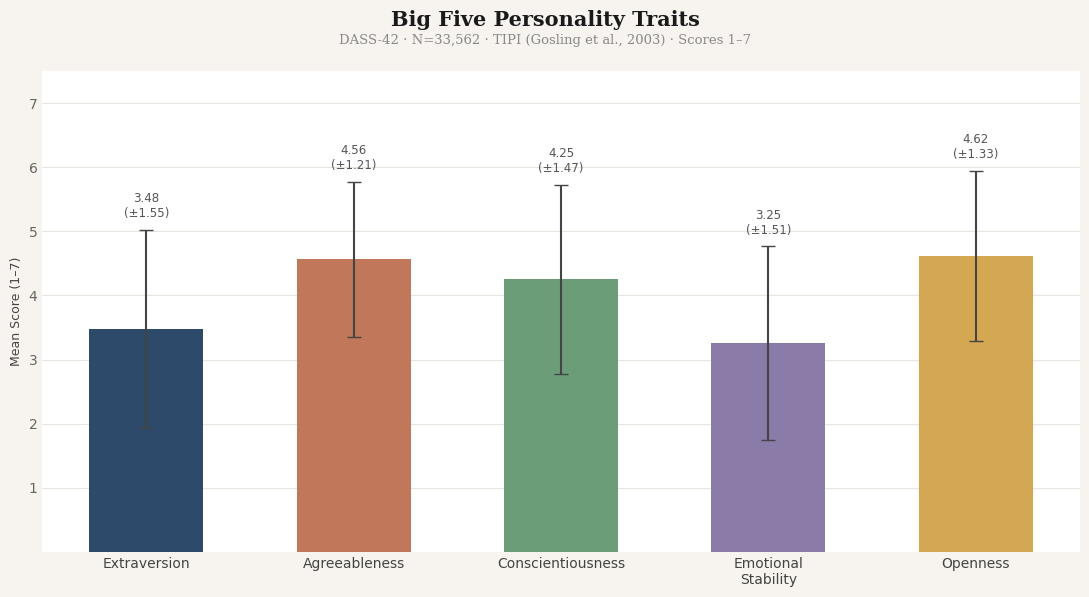

In [32]:
# Big Five descriptive statistics

big_five = ['extraversion', 'agreeableness', 'conscientiousness',
            'emotional_stability', 'openness']

print("Big Five Personality Traits — Descriptive Statistics")
print(f"{'─'*55}")
print(df_clean[big_five].agg(['mean', 'std', 'min', 'max']).round(2).T)

# --- Visualization ---
BIG5_COLORS = ['#2D4A6B', '#C1775A', '#6B9E78', '#8B7BA8', '#D4A853']
BIG5_LABELS = ['Extraversion', 'Agreeableness', 'Conscientiousness',
               'Emotional\nStability', 'Openness']

fig, ax = plt.subplots(figsize=(11, 6), facecolor='#F7F4EF')
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

means = df_clean[big_five].mean()
sds   = df_clean[big_five].std()
x     = range(len(big_five))

bars = ax.bar(x, means, color=BIG5_COLORS, edgecolor='none',
              width=0.55, zorder=3)

# Error bars showing ±1 SD
ax.errorbar(x, means, yerr=sds,
            fmt='none',
            ecolor='#444444',
            elinewidth=1.5,
            capsize=5,
            zorder=4)

ax.set_ylim(0, 7.5)
ax.set_xticks(x)
ax.set_xticklabels(BIG5_LABELS, fontsize=10, color='#444444')
ax.set_ylabel('Mean Score (1–7)', fontsize=9, color='#444444')
ax.set_yticks([1, 2, 3, 4, 5, 6, 7])

for i, (m, s) in enumerate(zip(means, sds)):
    ax.text(i, m + s + 0.15, f'{m:.2f}\n(±{s:.2f})',
            ha='center', va='bottom', fontsize=8.5, color='#555555')

fig.text(0.5, 0.96, 'Big Five Personality Traits',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · TIPI (Gosling et al., 2003) · Scores 1–7',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

## Primary Analyses

The following analyses examine DASS-42 scores across demographic and social variables
using one-way ANOVAs with Tukey HSD post-hoc tests, independent samples t-tests,
and Pearson correlations where appropriate. Two-way ANOVAs are used to test
interaction effects between selected variable pairs.

Descriptive Statistics — Gender × DASS
──────────────────────────────────────────────────
             depression        anxiety        stress       
                   mean    std    mean    std   mean    std
gender_label                                               
Female            20.72  11.97   16.32   9.85  21.45  10.15
Male              20.07  12.30   13.11   9.38  18.41  10.21
Other             26.29  11.21   19.84  10.28  24.49   9.55

ANOVA — depression: F = 56.59, p = 0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Female   Male  -0.6587 0.0001 -1.0306 -0.2868   True
Female  Other   5.5624    0.0  4.1937  6.9312   True
  Male  Other   6.2211    0.0  4.8247  7.6175   True
----------------------------------------------------

ANOVA — anxiety: F = 353.58, p = 0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper

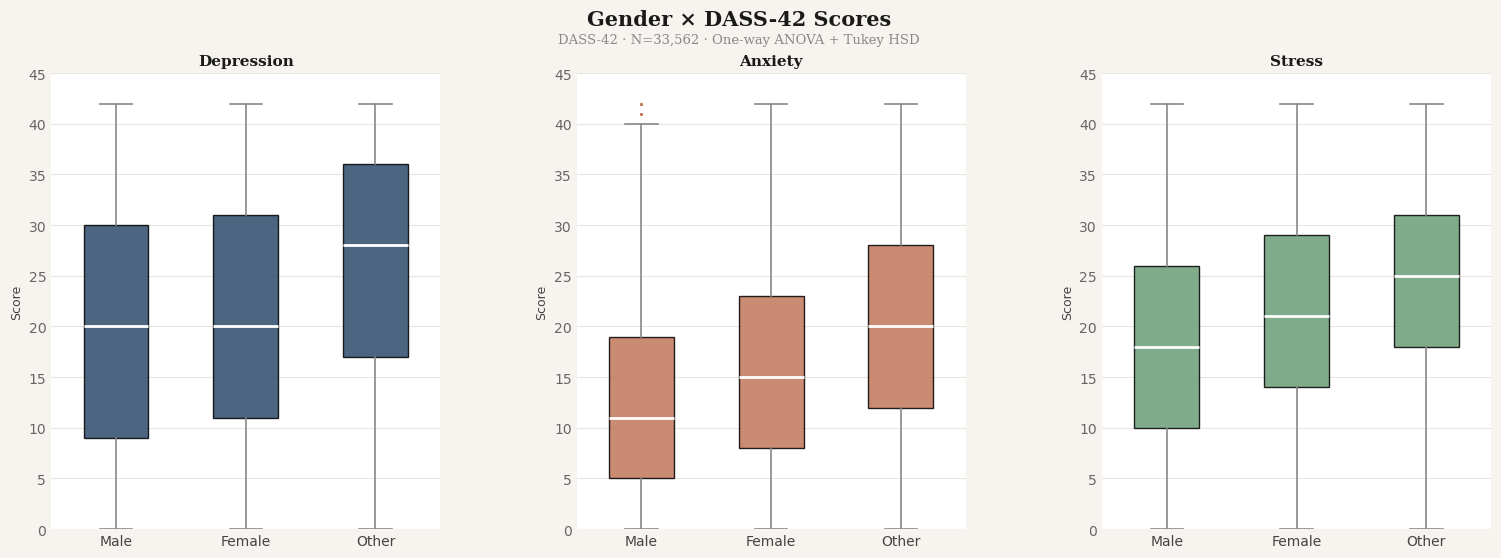

In [33]:
# Gender × DASS 


# --- Descriptive statistics ---
print("Descriptive Statistics — Gender × DASS")
print(f"{'─'*50}")
print(df_clean.groupby('gender_label')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2))

# --- One-way ANOVA + Tukey HSD ---
gender_order = ['Male', 'Female', 'Other']

for subscale in ['depression', 'anxiety', 'stress']:
    groups = [df_clean[df_clean['gender_label'] == g][subscale]
              for g in gender_order]

    F, p = stats.f_oneway(*groups)
    print(f"\nANOVA — {subscale}: F = {F:.2f}, p = {p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_clean[subscale],
            groups=df_clean['gender_label'],
            alpha=0.05
        )
        print(tukey.summary())

# --- Visualization ---
subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [df_clean[df_clean['gender_label'] == g][subscale].values
            for g in gender_order]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=2, alpha=0.3,
                                   markeredgewidth=0),
                    zorder=3)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(gender_order) + 1))
    ax.set_xticklabels(gender_order, fontsize=10, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)

fig.text(0.5, 0.96, 'Gender × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · One-way ANOVA + Tukey HSD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Descriptive Statistics — Region × DASS
──────────────────────────────────────────────────
                depression        anxiety        stress       
                      mean    std    mean    std   mean    std
region                                                        
Other                21.93  12.27   14.89  10.04  20.65  10.25
Southeast Asian      20.03  11.87   16.16   9.71  20.67  10.21
Western              21.60  12.30   14.80  10.04  21.17  10.31

ANOVA — depression: F = 73.69, p = 0.0000
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
          Other Southeast Asian  -1.8936    0.0 -2.4698 -1.3175   True
          Other         Western  -0.3267 0.4225 -0.9383  0.2849  False
Southeast Asian         Western   1.5669    0.0  1.2233  1.9106   True
---------------------------------------------------------------

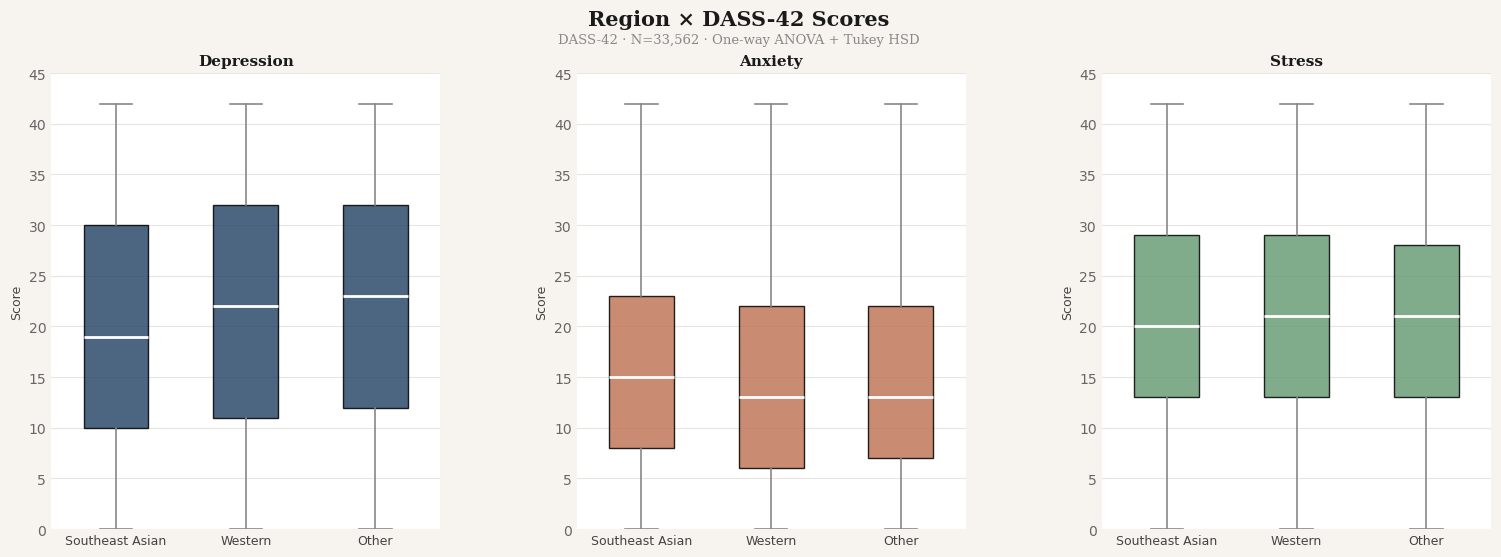

In [34]:
# Region × DASS 


region_order = ['Southeast Asian', 'Western', 'Other']
subscales    = ['depression', 'anxiety', 'stress']
colors       = ['#2D4A6B', '#C1775A', '#6B9E78']
titles       = ['Depression', 'Anxiety', 'Stress']

# --- Descriptive statistics ---
print("Descriptive Statistics — Region × DASS")
print(f"{'─'*50}")
print(df_clean.groupby('region')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2))

# --- One-way ANOVA + Tukey HSD ---
for subscale in subscales:
    groups = [df_clean[df_clean['region'] == g][subscale]
              for g in region_order]

    F, p = stats.f_oneway(*groups)
    print(f"\nANOVA — {subscale}: F = {F:.2f}, p = {p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_clean[subscale],
            groups=df_clean['region'],
            alpha=0.05
        )
        print(tukey.summary())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [df_clean[df_clean['region'] == g][subscale].values
            for g in region_order]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=2, alpha=0.3,
                                   markeredgewidth=0),
                    zorder=3)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(region_order) + 1))
    ax.set_xticklabels(region_order, fontsize=9, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)

fig.text(0.5, 0.96, 'Region × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · One-way ANOVA + Tukey HSD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

N for this analysis: 33,130
(Excluded 'Other' gender: n=437, 1.3% of sample)

───────────────────────────────────────────────────────
Two-way ANOVA — Depression
───────────────────────────────────────────────────────
                                 sum_sq       df        F  PR(>F)
C(gender_label)            5.796636e+03      1.0  40.1606     0.0
C(region)                  2.054090e+04      2.0  71.1564     0.0
C(gender_label):C(region)  6.772796e+03      2.0  23.4619     0.0
Residual                   4.780996e+06  33124.0      NaN     NaN

───────────────────────────────────────────────────────
Two-way ANOVA — Anxiety
───────────────────────────────────────────────────────
                                 sum_sq       df         F  PR(>F)
C(gender_label)            4.986550e+04      1.0  526.0319  0.0000
C(region)                  7.894925e+03      2.0   41.6418  0.0000
C(gender_label):C(region)  8.449803e+02      2.0    4.4569  0.0116
Residual                   3.140009e+06  33124.0

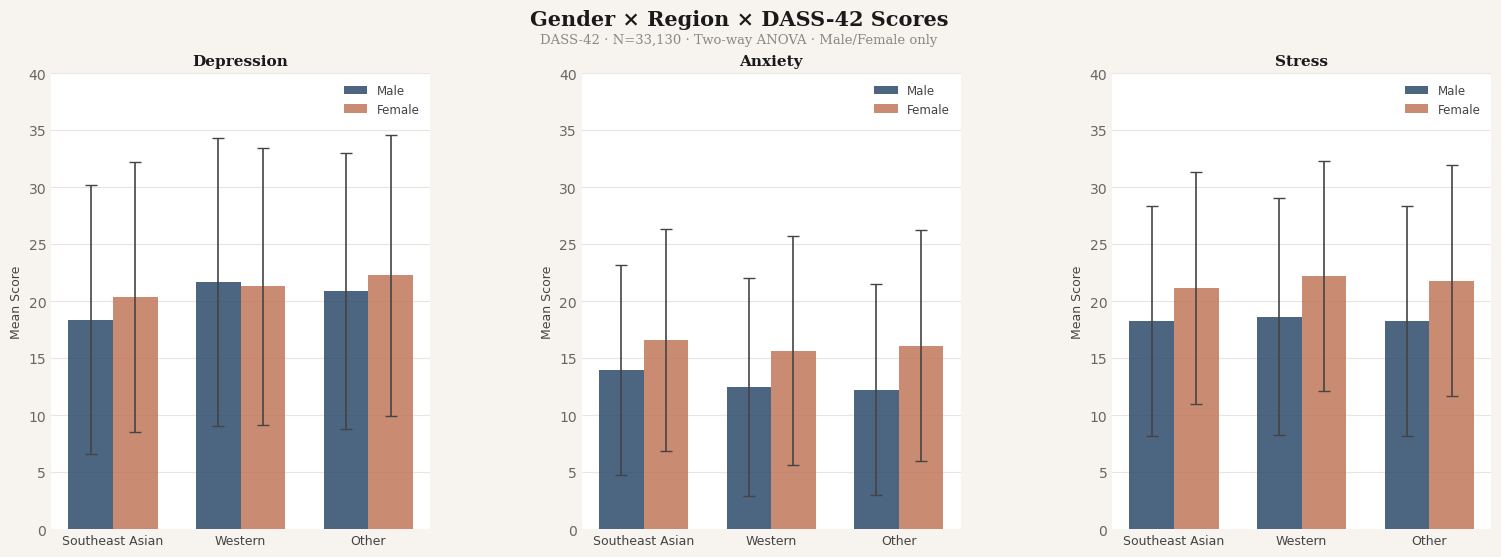

In [35]:
# Gender × Region × DASS (Two-way ANOVA) 


# Keeping only Male/Female for this analysis — 
# "Other" gender n=437 too small for a reliable interaction across 3 regions
df_43 = df_clean[df_clean['gender_label'].isin(['Male', 'Female'])].copy()

print(f"N for this analysis: {len(df_43):,}")
print(f"(Excluded 'Other' gender: n=437, 1.3% of sample)\n")

# --- Two-way ANOVA for each subscale ---
for subscale in ['depression', 'anxiety', 'stress']:
    print(f"{'─'*55}")
    print(f"Two-way ANOVA — {subscale.capitalize()}")
    print(f"{'─'*55}")

    # Formula syntax: outcome ~ factor1 + factor2 + factor1:factor2
    # The colon (:) means interaction term
    # C() tells statsmodels to treat the variable as categorical
    model  = ols(f'{subscale} ~ C(gender_label) + C(region) + C(gender_label):C(region)',
                 data=df_43).fit()
    table  = anova_lm(model, typ=2)
    print(table.round(4))
    print()

# --- Visualization: mean scores by gender × region ---
region_order = ['Southeast Asian', 'Western', 'Other']
gender_order = ['Male', 'Female']
colors_gender = {'Male': '#2D4A6B', 'Female': '#C1775A'}
subscales = ['depression', 'anxiety', 'stress']
titles    = ['Depression', 'Anxiety', 'Stress']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.4, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

x = range(len(region_order))
width = 0.35

for ax, subscale, title in zip(axes, subscales, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    for i, gender in enumerate(gender_order):
        means = [df_43[(df_43['gender_label'] == gender) &
                       (df_43['region'] == r)][subscale].mean()
                 for r in region_order]
        sds   = [df_43[(df_43['gender_label'] == gender) &
                       (df_43['region'] == r)][subscale].std()
                 for r in region_order]

        offset = (i - 0.5) * width
        bars   = ax.bar([xi + offset for xi in x],
                        means,
                        width=width,
                        color=colors_gender[gender],
                        edgecolor='none',
                        alpha=0.85,
                        zorder=3,
                        label=gender)
        ax.errorbar([xi + offset for xi in x],
                    means, yerr=sds,
                    fmt='none', ecolor='#444444',
                    elinewidth=1.2, capsize=4, zorder=4)

    ax.set_xticks(list(x))
    ax.set_xticklabels(region_order, fontsize=9, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Mean Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 40)
    ax.legend(fontsize=8.5, frameon=False, labelcolor='#444444')

fig.text(0.5, 0.96, 'Gender × Region × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={len(df_43):,} · Two-way ANOVA · Male/Female only',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Descriptive Statistics — Education × DASS
──────────────────────────────────────────────────
                       depression        anxiety        stress       
                             mean    std    mean    std   mean    std
education_label                                                      
Less than\nhigh school      23.81  11.89   18.70  10.11  23.57   9.91
High school                 21.93  11.91   16.76   9.91  21.68  10.12
University                  19.59  11.89   14.84   9.55  20.04  10.16
Graduate                    17.93  12.17   12.80   9.42  18.70  10.42

ANOVA — depression: F = 232.80, p = 0.0000
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------
             Graduate           High school   4.0003   0.0  3.4647  4.5359   True
             Graduate Less than
high school  

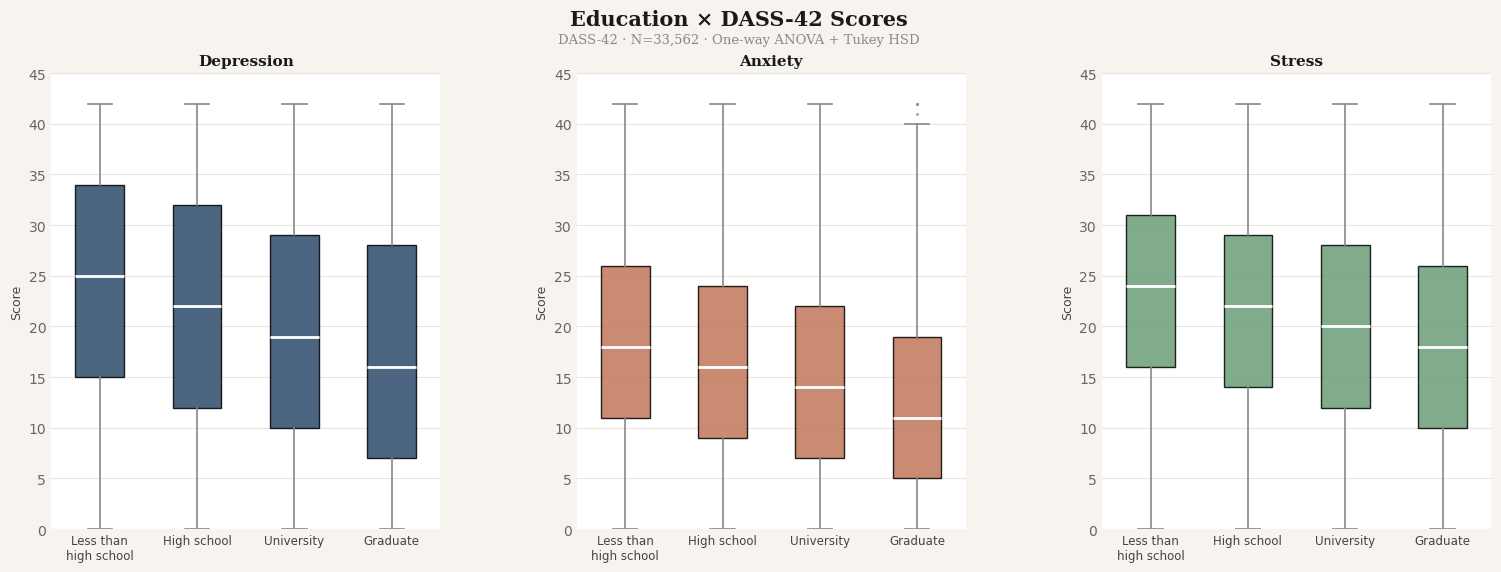

In [36]:
# Education × DASS


edu_order = ['Less than\nhigh school', 'High school', 'University', 'Graduate']
subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

# --- Descriptive statistics ---
print("Descriptive Statistics — Education × DASS")
print(f"{'─'*50}")
print(df_clean.groupby('education_label')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2)
      .reindex(edu_order))

# --- One-way ANOVA + Tukey HSD ---
for subscale in subscales:
    groups = [df_clean[df_clean['education_label'] == g][subscale]
              for g in edu_order]

    F, p = stats.f_oneway(*groups)
    print(f"\nANOVA — {subscale}: F = {F:.2f}, p = {p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_clean[subscale],
            groups=df_clean['education_label'],
            alpha=0.05
        )
        print(tukey.summary())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [df_clean[df_clean['education_label'] == g][subscale].values
            for g in edu_order]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=2, alpha=0.3,
                                   markeredgewidth=0),
                    zorder=3)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(edu_order) + 1))
    ax.set_xticklabels(edu_order, fontsize=8.5, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)

fig.text(0.5, 0.96, 'Education × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · One-way ANOVA + Tukey HSD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Descriptive Statistics — Religion × DASS
──────────────────────────────────────────────────
               depression        anxiety        stress       
                     mean    std    mean    std   mean    std
religion_label                                               
Muslim              19.96  11.83   16.18   9.69  20.65  10.23
Christian           20.35  12.20   14.82   9.96  20.89  10.28
Agnostic            22.81  12.00   14.77   9.70  21.22   9.90
Atheist             23.35  12.26   14.97  10.22  21.00  10.27
Other               22.17  12.36   16.58  10.65  22.25  10.47

ANOVA — depression: F = 84.61, p = 0.0000
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
 Agnostic   Atheist    0.544 0.4146 -0.3131  1.4012  False
 Agnostic Christian  -2.4507    0.0 -3.2117 -1.6897   True
 Agnostic    Muslim  -2.8478    0.0  -3.519 -2.1766   True
 Agnostic     O

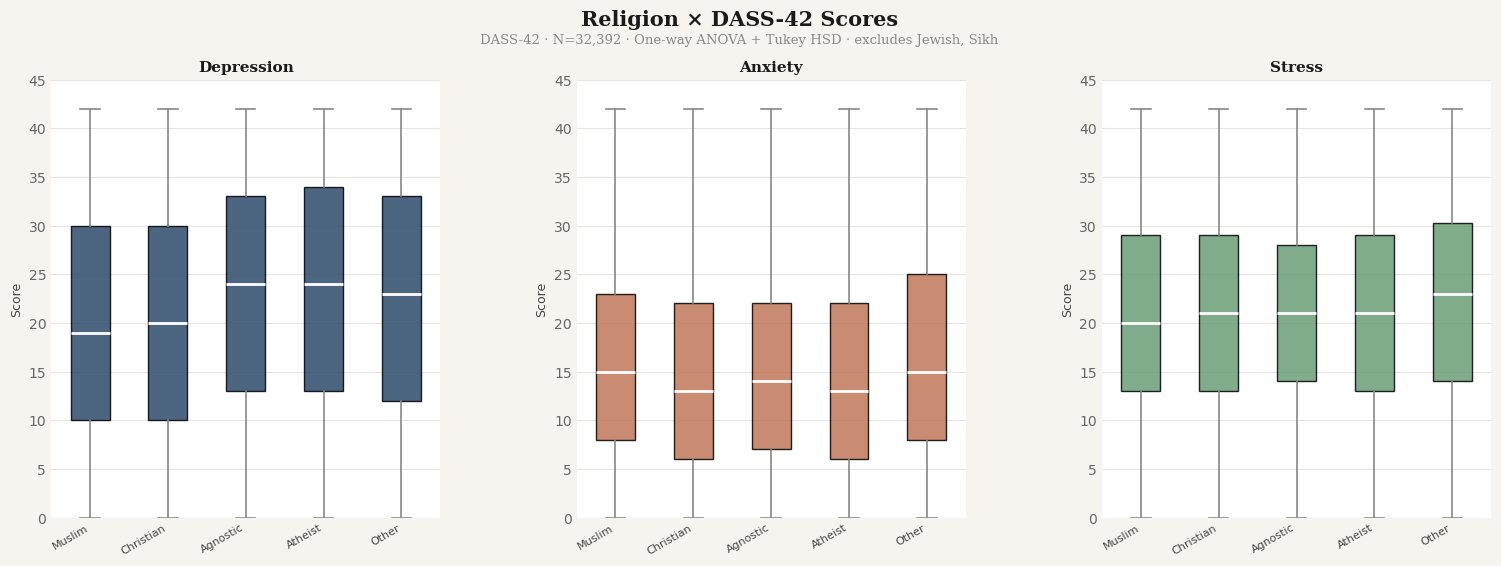

In [37]:
# Religion × DASS


# Using df_religion (excludes Jewish n=105 and Sikh n=58)
religion_order = ['Muslim','Christian', 'Agnostic', 'Atheist', 'Other']
subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

# --- Descriptive statistics ---
print("Descriptive Statistics — Religion × DASS")
print(f"{'─'*50}")
print(df_religion.groupby('religion_label')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2)
      .reindex(religion_order))

# --- One-way ANOVA + Tukey HSD ---
for subscale in subscales:
    groups = [df_religion[df_religion['religion_label'] == g][subscale]
              for g in religion_order]

    F, p = stats.f_oneway(*groups)
    print(f"\nANOVA — {subscale}: F = {F:.2f}, p = {p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_religion[subscale],
            groups=df_religion['religion_label'],
            alpha=0.05
        )
        print(tukey.summary())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.15,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [df_religion[df_religion['religion_label'] == g][subscale].values
            for g in religion_order]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=2, alpha=0.3,
                                   markeredgewidth=0),
                    zorder=3)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(religion_order) + 1))
    ax.set_xticklabels(religion_order, fontsize=8, color='#444444',
                       rotation=30, ha='right')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)

fig.text(0.5, 0.97, 'Religion × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.94, f'DASS-42 · N={len(df_religion):,} · One-way ANOVA + Tukey HSD · excludes Jewish, Sikh',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

N for this analysis: 31,285
(Excluded 'Not reported': n=2,277)

orientation_label
Heterosexual    21109
Bisexual         4058
Other            2845
Asexual          1682
Homosexual       1591
Name: count, dtype: int64

Descriptive Statistics — Orientation × DASS
──────────────────────────────────────────────────
                  depression        anxiety        stress       
                        mean    std    mean    std   mean    std
orientation_label                                               
Heterosexual           19.75  12.04   14.57   9.58  20.04  10.22
Bisexual               23.71  11.73   18.03  10.04  23.25   9.80
Homosexual             22.18  11.96   16.53  10.01  21.55  10.14
Asexual                21.77  12.27   17.00  10.24  21.23  10.35
Other                  21.90  11.99   18.07  10.30  22.32  10.35

ANOVA — depression: F = 113.40, p = 0.0000
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper 

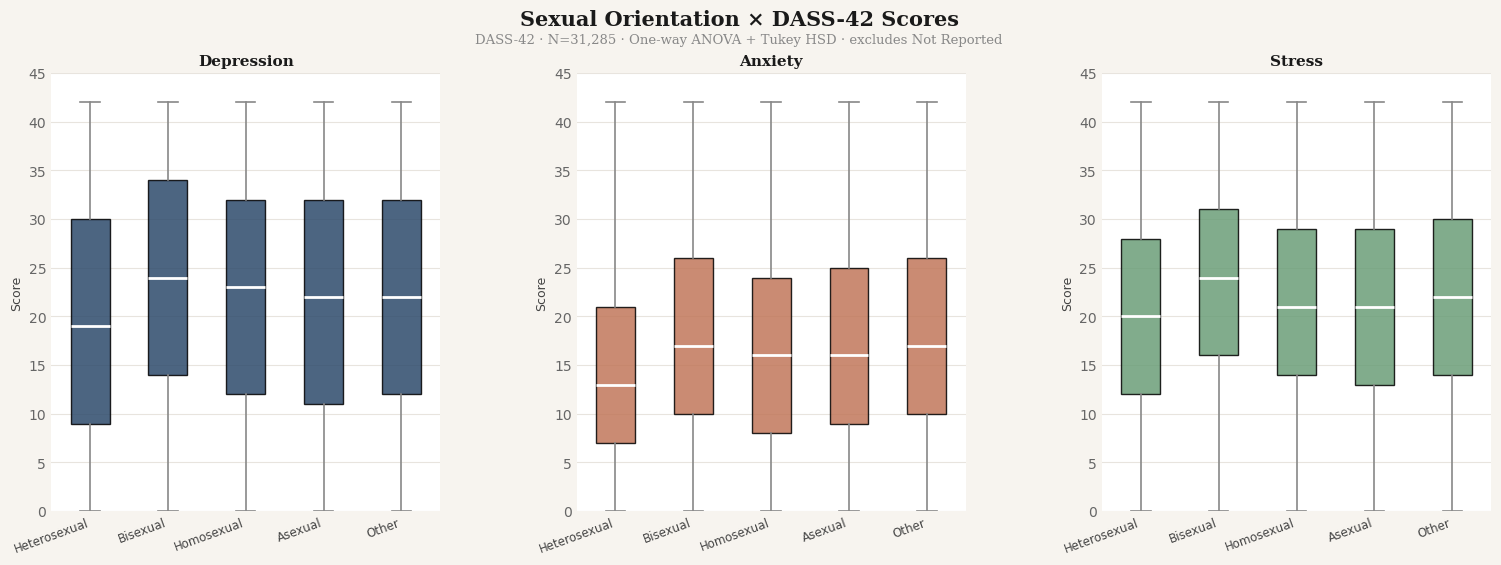

In [38]:
# Orientation × DASS


# Excluding 'Not reported' (orientation_missing flag)
df_orientation = df_clean[df_clean['orientation_missing'] == 0].copy()
print(f"N for this analysis: {len(df_orientation):,}")
print(f"(Excluded 'Not reported': n={df_clean['orientation_missing'].sum():,})\n")
print(df_orientation['orientation_label'].value_counts())

orientation_order = ['Heterosexual', 'Bisexual', 'Homosexual', 'Asexual', 'Other']
subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

# --- Descriptive statistics ---
print("\nDescriptive Statistics — Orientation × DASS")
print(f"{'─'*50}")
print(df_orientation.groupby('orientation_label')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2)
      .reindex(orientation_order))

# --- One-way ANOVA + Tukey HSD ---
for subscale in subscales:
    groups = [df_orientation[df_orientation['orientation_label'] == g][subscale]
              for g in orientation_order]

    F, p = stats.f_oneway(*groups)
    print(f"\nANOVA — {subscale}: F = {F:.2f}, p = {p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_orientation[subscale],
            groups=df_orientation['orientation_label'],
            alpha=0.05
        )
        print(tukey.summary())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.15,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [df_orientation[df_orientation['orientation_label'] == g][subscale].values
            for g in orientation_order]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=2, alpha=0.3,
                                   markeredgewidth=0),
                    zorder=3)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(orientation_order) + 1))
    ax.set_xticklabels(orientation_order, fontsize=8.5, color='#444444',
                       rotation=20, ha='right')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)

fig.text(0.5, 0.96, 'Sexual Orientation × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={len(df_orientation):,} · One-way ANOVA + Tukey HSD · excludes Not Reported',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

N for this analysis: 30,156

Group sizes:
religion_label     Agnostic  Atheist  Christian  Muslim  Other
orientation_label                                             
Asexual                 109      184        192    1108     48
Bisexual                711      790        673    1415    311
Heterosexual           1528     1725       4258   11996    799
Homosexual              200      247        225     738    110
Other                   142      169        275    2018    185

───────────────────────────────────────────────────────
Two-way ANOVA — Depression
───────────────────────────────────────────────────────
                                              sum_sq       df        F  PR(>F)
C(orientation_label)                    4.643919e+04      4.0  81.5436     0.0
C(religion_label)                       3.145896e+04      4.0  55.2395     0.0
C(orientation_label):C(religion_label)  1.290287e+04     16.0   5.6641     0.0
Residual                                4.289914e+06  30131.0

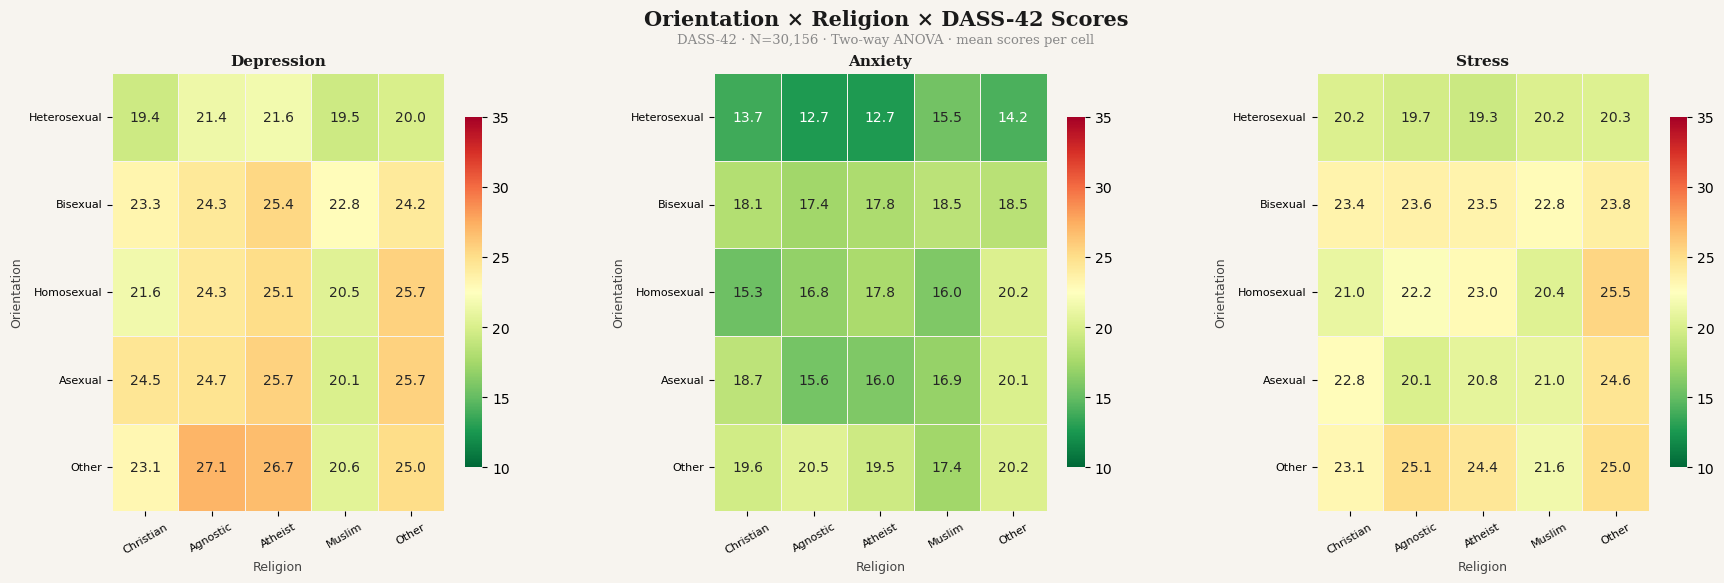

In [39]:
#  Orientation × Religion × DASS (Two-way ANOVA) 


# Applying both filters: valid orientation + valid religion
df_47 = df_clean[
    (df_clean['orientation_missing'] == 0) &
    (df_clean['religion_label'].isin(['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other']))
].copy()

print(f"N for this analysis: {len(df_47):,}")
print("\nGroup sizes:")
print(pd.crosstab(df_47['orientation_label'], df_47['religion_label']))

orientation_order = ['Heterosexual', 'Bisexual', 'Homosexual', 'Asexual', 'Other']
religion_order    = ['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other']
subscales         = ['depression', 'anxiety', 'stress']
titles            = ['Depression', 'Anxiety', 'Stress']

# --- Two-way ANOVA for each subscale ---
for subscale in subscales:
    print(f"\n{'─'*55}")
    print(f"Two-way ANOVA — {subscale.capitalize()}")
    print(f"{'─'*55}")
    model = ols(f'{subscale} ~ C(orientation_label) + C(religion_label) + C(orientation_label):C(religion_label)',
                data=df_47).fit()
    table = anova_lm(model, typ=2)
    print(table.round(4))

# --- Visualization: heatmap of mean scores ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.45, top=0.88, bottom=0.15,
                    left=0.07, right=0.97)

for ax, subscale, title in zip(axes, subscales, titles):
    # Build mean matrix: rows = orientation, cols = religion
    matrix = pd.DataFrame(index=orientation_order, columns=religion_order, dtype=float)
    for o in orientation_order:
        for r in religion_order:
            cell = df_47[(df_47['orientation_label'] == o) &
                         (df_47['religion_label'] == r)][subscale]
            matrix.loc[o, r] = cell.mean()

    sns.heatmap(matrix.astype(float),
                ax=ax,
                cmap='RdYlGn_r',
                vmin=10, vmax=35,
                annot=True, fmt='.1f',
                linewidths=0.5,
                linecolor='#F7F4EF',
                cbar_kws={'shrink': 0.8})

    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_xlabel('Religion', fontsize=9, color='#444444')
    ax.set_ylabel('Orientation', fontsize=9, color='#444444')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.text(0.5, 0.96, 'Orientation × Religion × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={len(df_47):,} · Two-way ANOVA · mean scores per cell',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Pearson Correlations — Family Size × DASS
──────────────────────────────────────────────────
Depression   r = -0.055, p = 0.0000
Anxiety      r = 0.010, p = 0.0800
Stress       r = -0.034, p = 0.0000


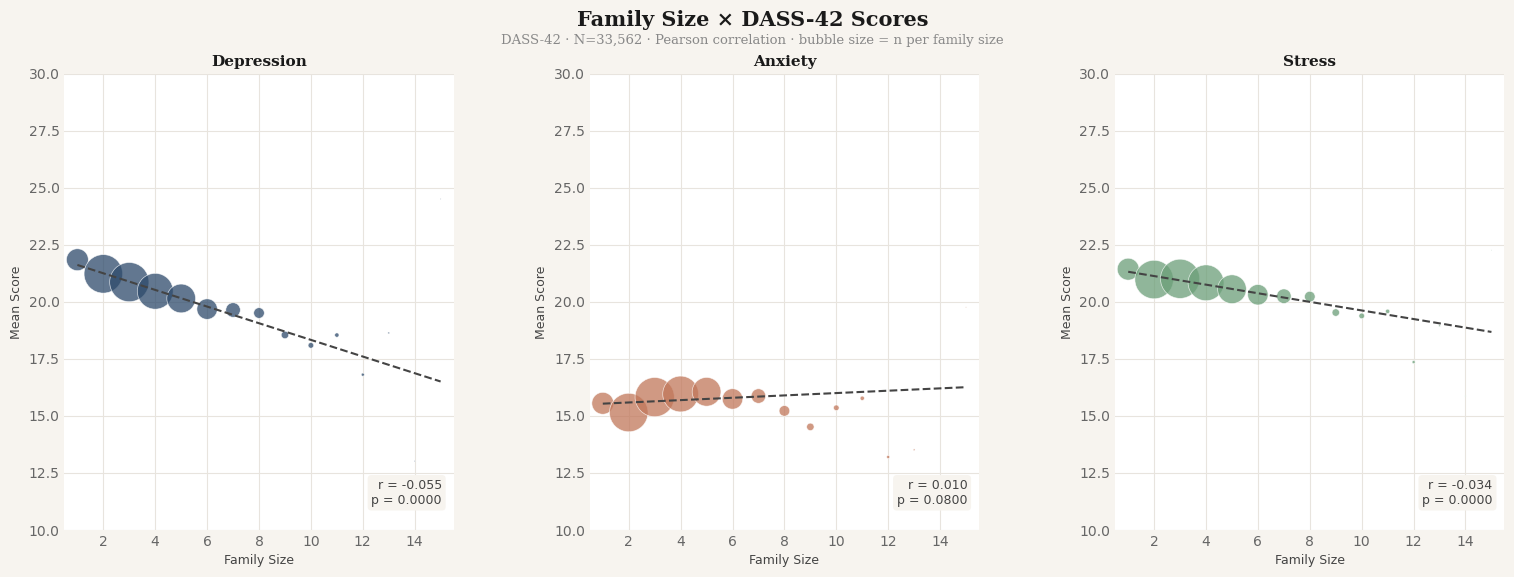

In [40]:
# Family Size × DASS


subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

# --- Correlations ---
print("Pearson Correlations — Family Size × DASS")
print(f"{'─'*50}")
for subscale in subscales:
    r, p = pearsonr(df_clean['familysize'], df_clean[subscale])
    print(f"{subscale.capitalize():12} r = {r:.3f}, p = {p:.4f}")

# --- Visualization: scatterplot with regression line ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)
    ax.grid(axis='x', color='#E8E4DE', linewidth=0.8, zorder=0)

    # Mean score per family size value
    means = df_clean.groupby('familysize')[subscale].mean()
    counts = df_clean.groupby('familysize')[subscale].count()

    # Scatter: one dot per family size, size reflects n
    ax.scatter(means.index, means.values,
               s=counts.values / 10,
               color=color, alpha=0.75,
               edgecolors='white', linewidth=0.5,
               zorder=3)

    # Regression line
    m, b = np.polyfit(df_clean['familysize'], df_clean[subscale], 1)
    x_line = np.linspace(1, 15, 100)
    ax.plot(x_line, m * x_line + b,
            color='#444444', linewidth=1.5,
            linestyle='--', zorder=4)

    r, p = pearsonr(df_clean['familysize'], df_clean[subscale])
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_xlabel('Family Size', fontsize=9, color='#444444')
    ax.set_ylabel('Mean Score', fontsize=9, color='#444444')
    ax.set_xlim(0.5, 15.5)
    ax.set_ylim(10, 30)
    ax.text(0.97, 0.05, f'r = {r:.3f}\np = {p:.4f}',
            transform=ax.transAxes,
            ha='right', va='bottom',
            fontsize=9, color='#444444',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#F7F4EF',
                      edgecolor='none'))

fig.text(0.5, 0.96, 'Family Size × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · Pearson correlation · bubble size = n per family size',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Descriptive Statistics — Family Size × Region
──────────────────────────────────────────────────
                 mean   std  median
region                             
Southeast Asian  4.16  1.84     4.0
Western          2.73  1.39     2.0
Other            2.70  1.48     2.0

ANOVA — familysize: F = 2843.79, p = 0.0000
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
          Other Southeast Asian   1.4583    0.0  1.3774  1.5391   True
          Other         Western    0.031 0.6745 -0.0548  0.1168  False
Southeast Asian         Western  -1.4273    0.0 -1.4755 -1.3791   True
----------------------------------------------------------------------


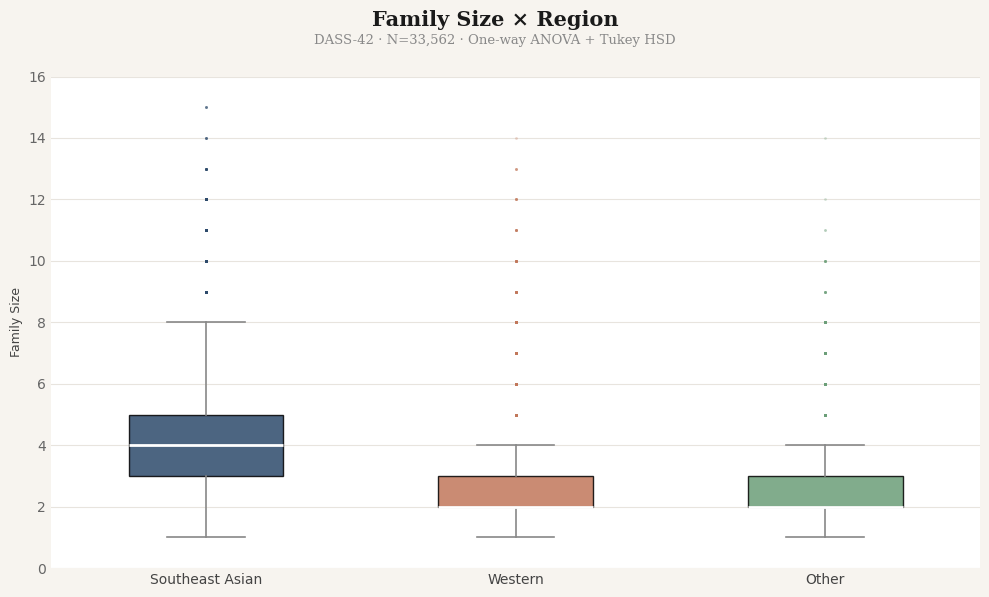

In [41]:
# Family Size × Region


region_order = ['Southeast Asian', 'Western', 'Other']

# --- Descriptive statistics ---
print("Descriptive Statistics — Family Size × Region")
print(f"{'─'*50}")
print(df_clean.groupby('region')['familysize']
      .agg(['mean', 'std', 'median'])
      .round(2)
      .reindex(region_order))

# --- One-way ANOVA + Tukey HSD ---
groups = [df_clean[df_clean['region'] == g]['familysize']
          for g in region_order]

F, p = stats.f_oneway(*groups)
print(f"\nANOVA — familysize: F = {F:.2f}, p = {p:.4f}")

if p < 0.05:
    tukey = pairwise_tukeyhsd(
        endog=df_clean['familysize'],
        groups=df_clean['region'],
        alpha=0.05
    )
    print(tukey.summary())

# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F7F4EF')
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

colors_region = ['#2D4A6B', '#C1775A', '#6B9E78']
data = [df_clean[df_clean['region'] == g]['familysize'].values
        for g in region_order]

bp = ax.boxplot(data,
                patch_artist=True,
                widths=0.5,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#888888', linewidth=1.2),
                capprops=dict(color='#888888', linewidth=1.2),
                flierprops=dict(marker='o', markersize=2,
                                alpha=0.3, markeredgewidth=0),
                zorder=3)

for patch, color in zip(bp['boxes'], colors_region):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, (g, color) in enumerate(zip(region_order, colors_region)):
    bp['fliers'][i].set_markerfacecolor(color)

ax.set_xticks(range(1, len(region_order) + 1))
ax.set_xticklabels(region_order, fontsize=10, color='#444444')
ax.set_ylabel('Family Size', fontsize=9, color='#444444')
ax.set_ylim(0, 16)

fig.text(0.5, 0.96, 'Family Size × Region',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · One-way ANOVA + Tukey HSD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

Descriptive Statistics — Family Size × Religion
──────────────────────────────────────────────────
                mean   std  median
religion_label                    
Christian       2.98  1.53     3.0
Agnostic        2.49  1.17     2.0
Atheist         2.47  1.16     2.0
Muslim          4.28  1.83     4.0
Other           2.76  1.45     2.0

ANOVA — familysize: F = 1773.43, p = 0.0000
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
 Agnostic   Atheist  -0.0241 0.9814 -0.1429  0.0946  False
 Agnostic Christian    0.493    0.0  0.3876  0.5983   True
 Agnostic    Muslim   1.7938    0.0  1.7008  1.8867   True
 Agnostic     Other   0.2725    0.0  0.1262  0.4189   True
  Atheist Christian   0.5171    0.0  0.4169  0.6173   True
  Atheist    Muslim   1.8179    0.0  1.7308   1.905   True
  Atheist     Other   0.2967    0.0   0.154  0.4393   True
Christian    Muslim  

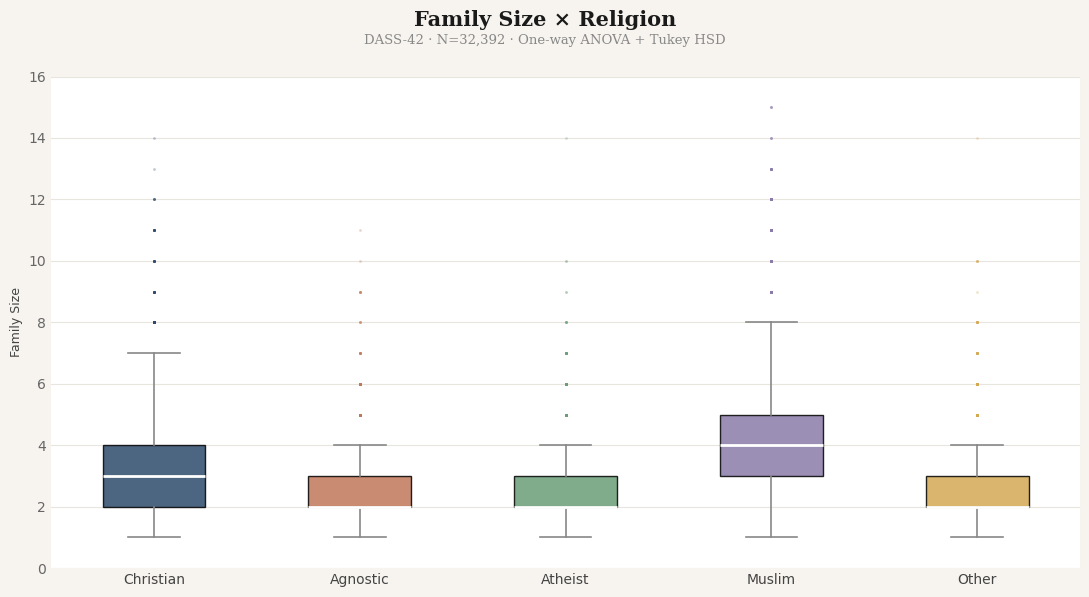

In [42]:
# Family Size × Religion


religion_order = ['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other']

# --- Descriptive statistics ---
print("Descriptive Statistics — Family Size × Religion")
print(f"{'─'*50}")
print(df_religion.groupby('religion_label')['familysize']
      .agg(['mean', 'std', 'median'])
      .round(2)
      .reindex(religion_order))

# --- One-way ANOVA + Tukey HSD ---
groups = [df_religion[df_religion['religion_label'] == g]['familysize']
          for g in religion_order]

F, p = stats.f_oneway(*groups)
print(f"\nANOVA — familysize: F = {F:.2f}, p = {p:.4f}")

if p < 0.05:
    tukey = pairwise_tukeyhsd(
        endog=df_religion['familysize'],
        groups=df_religion['religion_label'],
        alpha=0.05
    )
    print(tukey.summary())

# --- Visualization ---
fig, ax = plt.subplots(figsize=(11, 6), facecolor='#F7F4EF')
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

colors_religion = [COLORS_CAT[i % len(COLORS_CAT)]
                   for i in range(len(religion_order))]
data = [df_religion[df_religion['religion_label'] == g]['familysize'].values
        for g in religion_order]

bp = ax.boxplot(data,
                patch_artist=True,
                widths=0.5,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#888888', linewidth=1.2),
                capprops=dict(color='#888888', linewidth=1.2),
                flierprops=dict(marker='o', markersize=2,
                                alpha=0.3, markeredgewidth=0),
                zorder=3)

for patch, color in zip(bp['boxes'], colors_religion):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, color in enumerate(colors_religion):
    bp['fliers'][i].set_markerfacecolor(color)

ax.set_xticks(range(1, len(religion_order) + 1))
ax.set_xticklabels(religion_order, fontsize=10, color='#444444')
ax.set_ylabel('Family Size', fontsize=9, color='#444444')
ax.set_ylim(0, 16)

fig.text(0.5, 0.96, 'Family Size × Religion',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={len(df_religion):,} · One-way ANOVA + Tukey HSD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

Descriptive Statistics — Marital Status × DASS
──────────────────────────────────────────────────
                    depression        anxiety       stress       
                          mean    std    mean   std   mean    std
marital_label                                                    
Never\nmarried           21.26  11.95   16.34  9.79  21.22  10.13
Married                  16.10  11.80   11.19  8.99  18.11  10.48
Previously\nmarried      20.14  12.55   12.57  9.90  19.07  11.02

ANOVA — depression: F = 308.66, p = 0.0000
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1          group2       meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------
      Married      Never
married   5.1526    0.0  4.6658  5.6393   True
      Married Previously
married   4.0338    0.0  3.0045  5.0631   True
Never
married Previously
married  -1.1188 0.0141 -2.0552 -0.1824   True
------------------------------

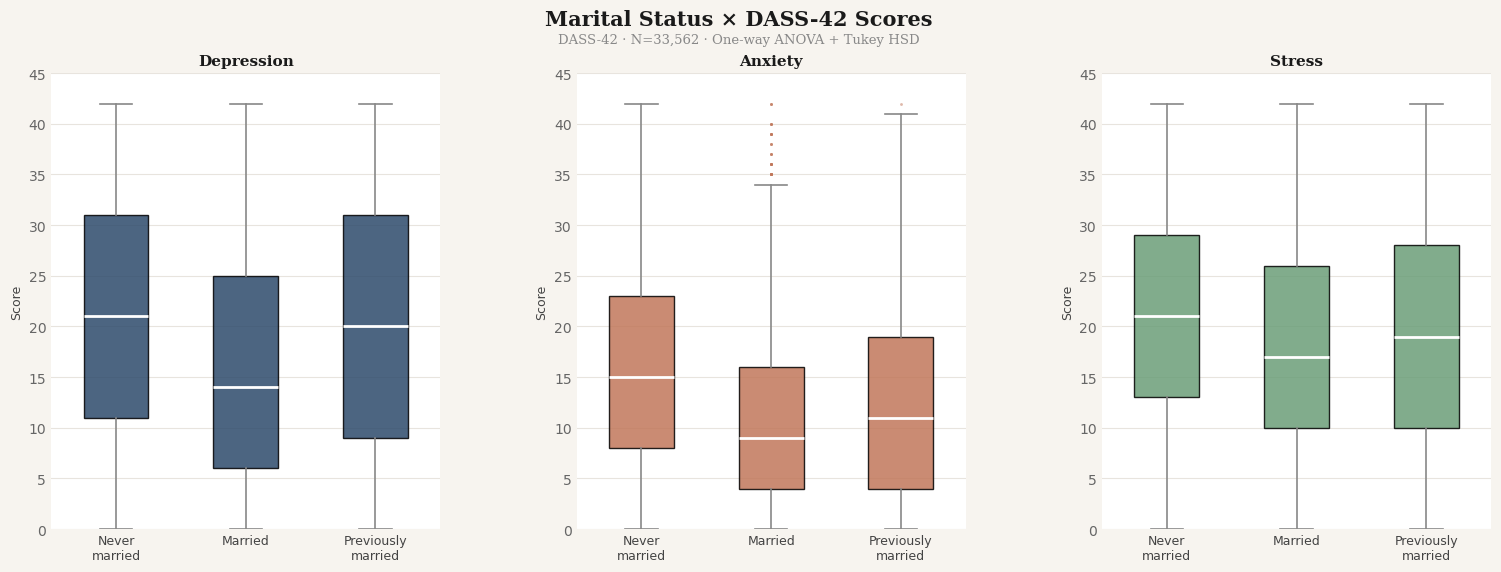

In [43]:
# Marital Status × DASS


marital_order = ['Never\nmarried', 'Married', 'Previously\nmarried']
subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

# --- Descriptive statistics ---
print("Descriptive Statistics — Marital Status × DASS")
print(f"{'─'*50}")
print(df_clean.groupby('marital_label')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2)
      .reindex(marital_order))

# --- One-way ANOVA + Tukey HSD ---
for subscale in subscales:
    groups = [df_clean[df_clean['marital_label'] == g][subscale]
              for g in marital_order]

    F, p = stats.f_oneway(*groups)
    print(f"\nANOVA — {subscale}: F = {F:.2f}, p = {p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_clean[subscale],
            groups=df_clean['marital_label'],
            alpha=0.05
        )
        print(tukey.summary())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [df_clean[df_clean['marital_label'] == g][subscale].values
            for g in marital_order]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=2, alpha=0.3,
                                   markeredgewidth=0),
                    zorder=3)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(marital_order) + 1))
    ax.set_xticklabels(marital_order, fontsize=9, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)

fig.text(0.5, 0.96, 'Marital Status × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · One-way ANOVA + Tukey HSD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

N for this analysis: 33,562

Group sizes:
region               Other  Southeast Asian  Western
marital_label                                       
Married                265             1961     1512
Never\nmarried        2351            18771     7779
Previously\nmarried     89              199      635

───────────────────────────────────────────────────────
Two-way ANOVA — Depression
───────────────────────────────────────────────────────
                                  sum_sq       df         F  PR(>F)
C(marital_label)            9.701825e+04      2.0  341.9746  0.0000
C(region)                   3.022548e+04      2.0  106.5402  0.0000
C(marital_label):C(region)  1.016706e+03      4.0    1.7919  0.1273
Residual                    4.759496e+06  33553.0       NaN     NaN

───────────────────────────────────────────────────────
Two-way ANOVA — Anxiety
───────────────────────────────────────────────────────
                                  sum_sq       df         F  PR(>F)
C(marita

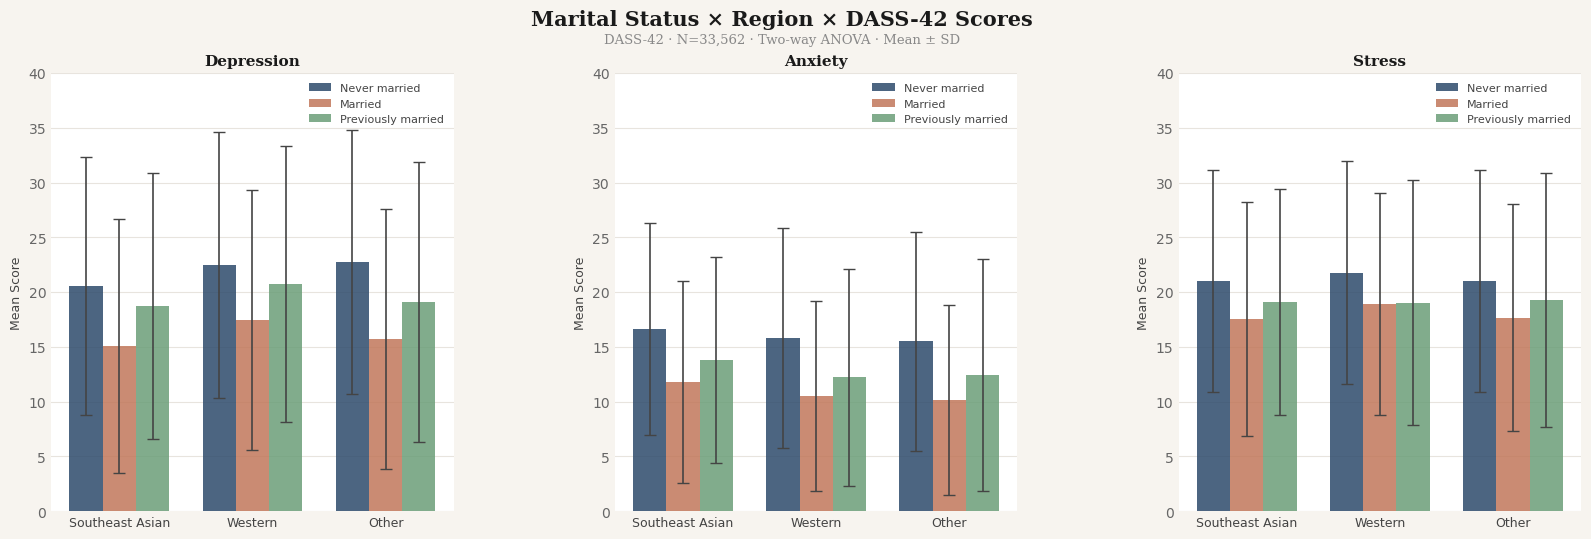

In [44]:
# Marital Status × Region × DASS (Two-way ANOVA)


marital_order = ['Never\nmarried', 'Married', 'Previously\nmarried']
region_order  = ['Southeast Asian', 'Western', 'Other']
subscales     = ['depression', 'anxiety', 'stress']
titles        = ['Depression', 'Anxiety', 'Stress']

print(f"N for this analysis: {len(df_clean):,}")
print("\nGroup sizes:")
print(pd.crosstab(df_clean['marital_label'], df_clean['region']))

# --- Two-way ANOVA ---
for subscale in subscales:
    print(f"\n{'─'*55}")
    print(f"Two-way ANOVA — {subscale.capitalize()}")
    print(f"{'─'*55}")
    model = ols(f'{subscale} ~ C(marital_label) + C(region) + C(marital_label):C(region)',
                data=df_clean).fit()
    table = anova_lm(model, typ=2)
    print(table.round(4))

# --- Visualization: grouped bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(17, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.4, top=0.88, bottom=0.15,
                    left=0.07, right=0.97)

colors_marital = {'Never\nmarried':      '#2D4A6B',
                  'Married':             '#C1775A',
                  'Previously\nmarried': '#6B9E78'}
x     = range(len(region_order))
width = 0.25

for ax, subscale, title in zip(axes, subscales, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    for i, marital in enumerate(marital_order):
        means = [df_clean[(df_clean['marital_label'] == marital) &
                          (df_clean['region'] == r)][subscale].mean()
                 for r in region_order]
        sds   = [df_clean[(df_clean['marital_label'] == marital) &
                          (df_clean['region'] == r)][subscale].std()
                 for r in region_order]

        offset = (i - 1) * width
        ax.bar([xi + offset for xi in x],
               means,
               width=width,
               color=colors_marital[marital],
               edgecolor='none',
               alpha=0.85,
               zorder=3,
               label=marital.replace('\n', ' '))
        ax.errorbar([xi + offset for xi in x],
                    means, yerr=sds,
                    fmt='none', ecolor='#444444',
                    elinewidth=1.2, capsize=4, zorder=4)

    ax.set_xticks(list(x))
    ax.set_xticklabels(region_order, fontsize=9, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Mean Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 40)
    ax.legend(fontsize=8, frameon=False, labelcolor='#444444')

fig.text(0.5, 0.96, 'Marital Status × Region × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · Two-way ANOVA · Mean ± SD',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

N for this analysis: 32,392

Group sizes:
religion_label       Agnostic  Atheist  Christian  Muslim  Other
marital_label                                                   
Married                   270      291       1002    1778    211
Never\nmarried           2322     2753       4461   17290   1145
Previously\nmarried       112      101        341     191    124

───────────────────────────────────────────────────────
Two-way ANOVA — Depression
───────────────────────────────────────────────────────
                                          sum_sq       df         F  PR(>F)
C(marital_label)                    8.400411e+04      2.0  298.0602  0.0000
C(religion_label)                   5.091146e+04      4.0   90.3211  0.0000
C(marital_label):C(religion_label)  2.540015e+03      8.0    2.2531  0.0211
Residual                            4.562502e+06  32377.0       NaN     NaN

───────────────────────────────────────────────────────
Two-way ANOVA — Anxiety
────────────────────────────────

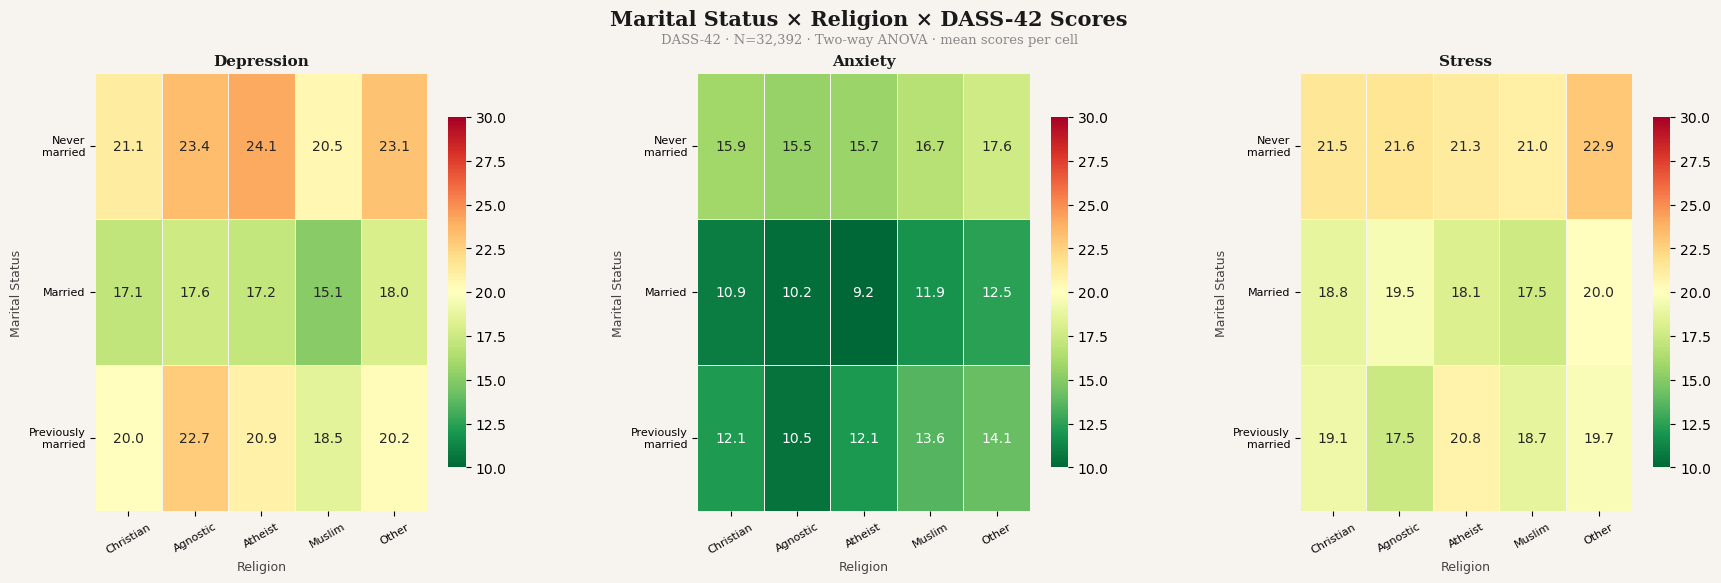

In [45]:
# Marital Status × Religion × DASS (Two-way ANOVA)


df_marital_religion = df_clean[
    df_clean['religion_label'].isin(['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other'])
].copy()

marital_order  = ['Never\nmarried', 'Married', 'Previously\nmarried']
religion_order = ['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other']
subscales      = ['depression', 'anxiety', 'stress']
titles         = ['Depression', 'Anxiety', 'Stress']

print(f"N for this analysis: {len(df_marital_religion):,}")
print("\nGroup sizes:")
print(pd.crosstab(df_marital_religion['marital_label'], df_marital_religion['religion_label']))

# --- Two-way ANOVA ---
for subscale in subscales:
    print(f"\n{'─'*55}")
    print(f"Two-way ANOVA — {subscale.capitalize()}")
    print(f"{'─'*55}")
    model = ols(f'{subscale} ~ C(marital_label) + C(religion_label) + C(marital_label):C(religion_label)',
                data=df_marital_religion).fit()
    table = anova_lm(model, typ=2)
    print(table.round(4))

# --- Visualization: heatmap of mean scores ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.45, top=0.88, bottom=0.15,
                    left=0.07, right=0.97)

for ax, subscale, title in zip(axes, subscales, titles):
    matrix = pd.DataFrame(index=marital_order,
                          columns=religion_order, dtype=float)
    for m in marital_order:
        for r in religion_order:
            cell = df_marital_religion[(df_marital_religion['marital_label'] == m) &
                                       (df_marital_religion['religion_label'] == r)][subscale]
            matrix.loc[m, r] = cell.mean()

    sns.heatmap(matrix.astype(float),
                ax=ax,
                cmap='RdYlGn_r',
                vmin=10, vmax=30,
                annot=True, fmt='.1f',
                linewidths=0.5,
                linecolor='#F7F4EF',
                cbar_kws={'shrink': 0.8})

    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_xlabel('Religion', fontsize=9, color='#444444')
    ax.set_ylabel('Marital Status', fontsize=9, color='#444444')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.text(0.5, 0.96, 'Marital Status × Religion × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={len(df_marital_religion):,} · Two-way ANOVA · mean scores per cell',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Descriptive Statistics — Voted × DASS
──────────────────────────────────────────────────
            depression        anxiety       stress       
                  mean    std    mean   std   mean    std
voted_label                                              
Yes              19.02  12.15   13.38  9.37  19.23  10.28
No               21.30  11.96   16.57  9.90  21.45  10.16

Group sizes: Yes=9,600, No=23,962

t-test — depression: t = -15.72, p = 0.0000

t-test — anxiety: t = -27.15, p = 0.0000

t-test — stress: t = -17.97, p = 0.0000


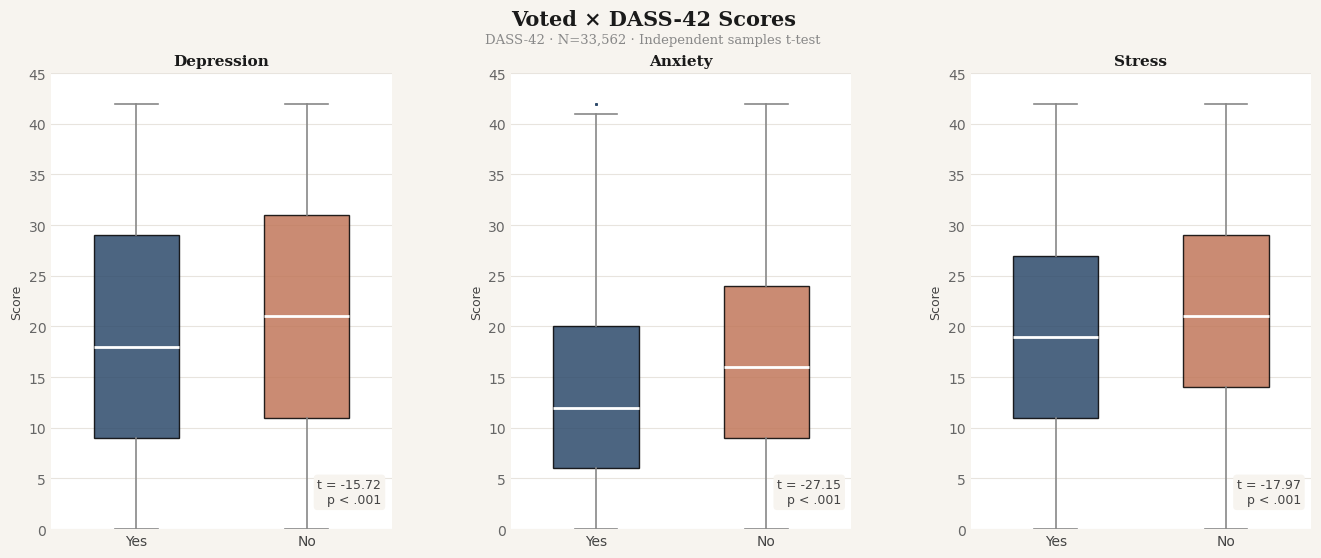

In [46]:
# Voted × DASS 


voted_order = ['Yes', 'No']
subscales   = ['depression', 'anxiety', 'stress']
colors      = ['#2D4A6B', '#C1775A']
titles      = ['Depression', 'Anxiety', 'Stress']

# --- Descriptive statistics ---
print("Descriptive Statistics — Voted × DASS")
print(f"{'─'*50}")
print(df_clean.groupby('voted_label')[['depression', 'anxiety', 'stress']]
      .agg(['mean', 'std'])
      .round(2)
      .reindex(voted_order))

# --- Independent samples t-test ---
yes = df_clean[df_clean['voted_label'] == 'Yes']
no  = df_clean[df_clean['voted_label'] == 'No']

print(f"\nGroup sizes: Yes={len(yes):,}, No={len(no):,}")

for subscale in subscales:
    t, p = stats.ttest_ind(yes[subscale], no[subscale])
    print(f"\nt-test — {subscale}: t = {t:.2f}, p = {p:.4f}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(14, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, title in zip(axes, subscales, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)

    data = [yes[subscale].values, no[subscale].values]

    bp = ax.boxplot(data,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888', linewidth=1.2),
                    capprops=dict(color='#888888', linewidth=1.2),
                    flierprops=dict(marker='o', markersize=2,
                                    alpha=0.3, markeredgewidth=0),
                    zorder=3)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)

    t, p = stats.ttest_ind(yes[subscale], no[subscale])
    p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'

    ax.set_xticks([1, 2])
    ax.set_xticklabels(voted_order, fontsize=10, color='#444444')
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_ylabel('Score', fontsize=9, color='#444444')
    ax.set_ylim(0, 45)
    ax.text(0.97, 0.05, f't = {t:.2f}\n{p_str}',
            transform=ax.transAxes,
            ha='right', va='bottom',
            fontsize=9, color='#444444',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#F7F4EF',
                      edgecolor='none'))

fig.text(0.5, 0.96, 'Voted × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · Independent samples t-test',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

In [47]:
# Voted × Age & Voted × Region

# --- Voted × Age ---
print("Age by Voted")
print(f"{'─'*40}")
print(df_clean.groupby('voted_label')['age']
      .agg(['mean', 'std', 'median'])
      .round(2)
      .reindex(voted_order))

# --- Voted × Region ---
print("\nRegion distribution by Voted")
print(f"{'─'*40}")
print(pd.crosstab(df_clean['voted_label'],
                  df_clean['region'],
                  normalize='index')
      .round(3)
      .reindex(voted_order) * 100)

Age by Voted
────────────────────────────────────────
              mean   std  median
voted_label                     
Yes          28.92  9.66    26.0
No           21.45  6.90    20.0

Region distribution by Voted
────────────────────────────────────────
region       Other  Southeast Asian  Western
voted_label                                 
Yes            7.8             58.7     33.5
No             8.2             63.8     28.0


Pearson Correlations — Age × DASS
──────────────────────────────────────────────────
Depression   r = -0.119, p < .001
Anxiety      r = -0.245, p < .001
Stress       r = -0.156, p < .001


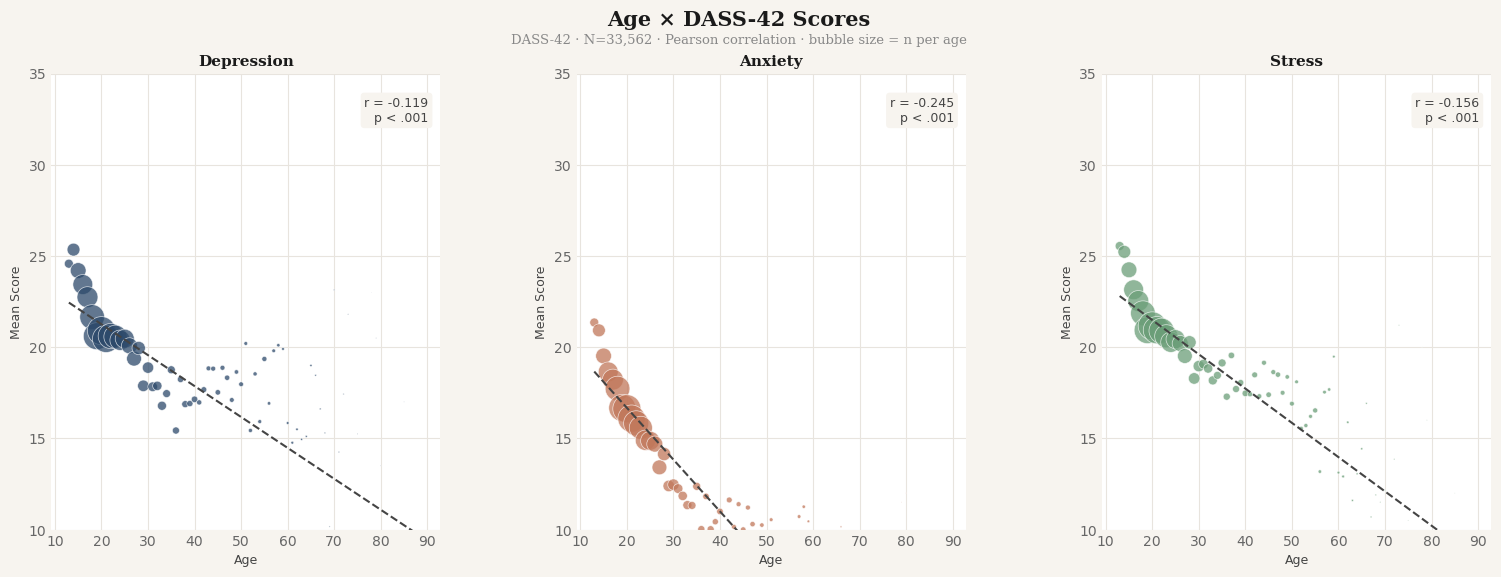

In [48]:
# Age × DASS


subscales = ['depression', 'anxiety', 'stress']
colors    = ['#2D4A6B', '#C1775A', '#6B9E78']
titles    = ['Depression', 'Anxiety', 'Stress']

# --- Correlations ---
print("Pearson Correlations — Age × DASS")
print(f"{'─'*50}")
for subscale in subscales:
    r, p = pearsonr(df_clean['age'], df_clean[subscale])
    p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'
    print(f"{subscale.capitalize():12} r = {r:.3f}, {p_str}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

for ax, subscale, color, title in zip(axes, subscales, colors, titles):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(axis='y', color='#E8E4DE', linewidth=0.8, zorder=0)
    ax.grid(axis='x', color='#E8E4DE', linewidth=0.8, zorder=0)

    # Mean score per age value
    means  = df_clean.groupby('age')[subscale].mean()
    counts = df_clean.groupby('age')[subscale].count()

    ax.scatter(means.index, means.values,
               s=counts.values / 8,
               color=color, alpha=0.75,
               edgecolors='white', linewidth=0.5,
               zorder=3)

    # Regression line
    m, b = np.polyfit(df_clean['age'], df_clean[subscale], 1)
    x_line = np.linspace(df_clean['age'].min(), df_clean['age'].max(), 100)
    ax.plot(x_line, m * x_line + b,
            color='#444444', linewidth=1.5,
            linestyle='--', zorder=4)

    r, p = pearsonr(df_clean['age'], df_clean[subscale])
    p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'

    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_xlabel('Age', fontsize=9, color='#444444')
    ax.set_ylabel('Mean Score', fontsize=9, color='#444444')
    ax.set_ylim(10, 35)
    ax.text(0.97, 0.95, f'r = {r:.3f}\n{p_str}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9, color='#444444',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#F7F4EF',
                      edgecolor='none'))

fig.text(0.5, 0.96, 'Age × DASS-42 Scores',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · Pearson correlation · bubble size = n per age',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

## Personality × DASS-42

The following analyses examine relationships between Big Five personality traits
(measured via TIPI, Gosling et al., 2003) and DASS-42 scores. Pearson correlations
are reported for the full sample and broken down by region to test cultural
generalizability of personality-distress associations.

Pearson Correlations — Big Five × DASS
───────────────────────────────────────────────────────
Extraversion           × Depression   r = -0.292, p < .001
Extraversion           × Anxiety      r = -0.178, p < .001
Extraversion           × Stress       r = -0.169, p < .001

Agreeableness          × Depression   r = -0.158, p < .001
Agreeableness          × Anxiety      r = -0.110, p < .001
Agreeableness          × Stress       r = -0.198, p < .001

Conscientiousness      × Depression   r = -0.290, p < .001
Conscientiousness      × Anxiety      r = -0.226, p < .001
Conscientiousness      × Stress       r = -0.219, p < .001

Emotional Stability    × Depression   r = -0.514, p < .001
Emotional Stability    × Anxiety      r = -0.532, p < .001
Emotional Stability    × Stress       r = -0.644, p < .001

Openness               × Depression   r = -0.232, p < .001
Openness               × Anxiety      r = -0.204, p < .001
Openness               × Stress       r = -0.194, p < .001



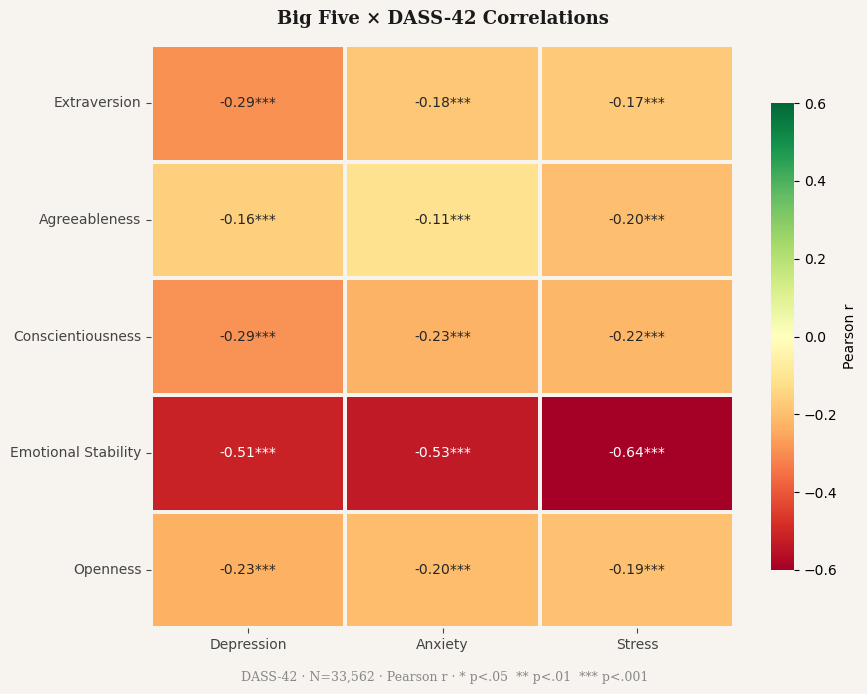

In [49]:
# Big Five × DASS


big_five  = ['extraversion', 'agreeableness', 'conscientiousness',
             'emotional_stability', 'openness']
subscales = ['depression', 'anxiety', 'stress']

bf_labels = ['Extraversion', 'Agreeableness', 'Conscientiousness',
             'Emotional Stability', 'Openness']
ss_labels = ['Depression', 'Anxiety', 'Stress']

# --- Correlation matrix + p-values ---
print("Pearson Correlations — Big Five × DASS")
print(f"{'─'*55}")
for trait, label in zip(big_five, bf_labels):
    for subscale, ss_label in zip(subscales, ss_labels):
        r, p = pearsonr(df_clean[trait], df_clean[subscale])
        p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'
        print(f"{label:22} × {ss_label:12} r = {r:.3f}, {p_str}")
    print()

# --- Build correlation matrix for heatmap ---
corr_matrix = pd.DataFrame(index=bf_labels, columns=ss_labels, dtype=float)
pval_matrix = pd.DataFrame(index=bf_labels, columns=ss_labels, dtype=float)

for trait, label in zip(big_five, bf_labels):
    for subscale, ss_label in zip(subscales, ss_labels):
        r, p = pearsonr(df_clean[trait], df_clean[subscale])
        corr_matrix.loc[label, ss_label] = r
        pval_matrix.loc[label, ss_label] = p

# --- Significance annotation ---
# * p<.05, ** p<.01, *** p<.001
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

annot_matrix = pd.DataFrame(index=bf_labels, columns=ss_labels)
for trait in bf_labels:
    for subscale in ss_labels:
        r = corr_matrix.loc[trait, subscale]
        p = pval_matrix.loc[trait, subscale]
        annot_matrix.loc[trait, subscale] = f'{r:.2f}{sig_stars(p)}'

# --- Visualization ---
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#F7F4EF')
ax.set_facecolor('#F7F4EF')

sns.heatmap(corr_matrix.astype(float),
            ax=ax,
            cmap='RdYlGn',
            vmin=-0.6, vmax=0.6,
            center=0,
            annot=annot_matrix,
            fmt='',
            linewidths=1.5,
            linecolor='#F7F4EF',
            cbar_kws={'shrink': 0.8,
                      'label': 'Pearson r'})

ax.set_title('Big Five × DASS-42 Correlations',
             fontsize=13, fontweight='bold',
             color='#1a1a1a', fontfamily='serif',
             pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=10, colors='#444444')
ax.tick_params(axis='y', labelsize=10, colors='#444444', rotation=0)

fig.text(0.5, 0.02,
         f'DASS-42 · N={N:,} · Pearson r · * p<.05  ** p<.01  *** p<.001',
         ha='center', fontsize=9, color='#888888', fontfamily='serif')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

Pearson Correlations — Big Five × DASS by Region

───────────────────────────────────────────────────────
Region: Southeast Asian (N=20,931)
───────────────────────────────────────────────────────
Extraversion           × Depression   r = -0.274, p < .001
Extraversion           × Anxiety      r = -0.196, p < .001
Extraversion           × Stress       r = -0.188, p < .001
Agreeableness          × Depression   r = -0.150, p < .001
Agreeableness          × Anxiety      r = -0.129, p < .001
Agreeableness          × Stress       r = -0.200, p < .001
Conscientiousness      × Depression   r = -0.300, p < .001
Conscientiousness      × Anxiety      r = -0.247, p < .001
Conscientiousness      × Stress       r = -0.263, p < .001
Emotional Stability    × Depression   r = -0.546, p < .001
Emotional Stability    × Anxiety      r = -0.537, p < .001
Emotional Stability    × Stress       r = -0.651, p < .001
Openness               × Depression   r = -0.253, p < .001
Openness               × Anxiety    

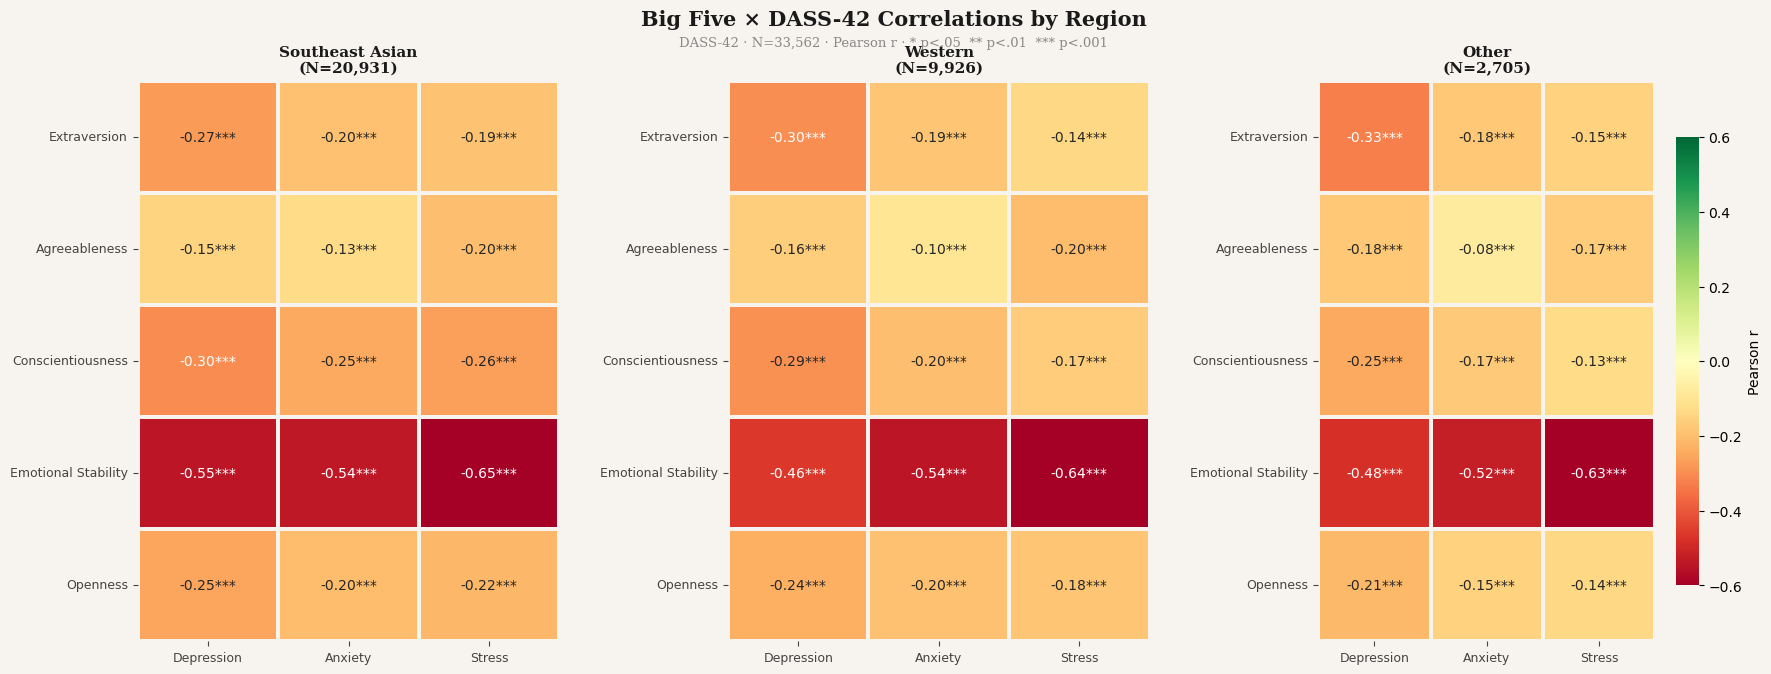

In [50]:
# Big Five × Region × DASS 


big_five  = ['extraversion', 'agreeableness', 'conscientiousness',
             'emotional_stability', 'openness']
subscales = ['depression', 'anxiety', 'stress']
bf_labels = ['Extraversion', 'Agreeableness', 'Conscientiousness',
             'Emotional Stability', 'Openness']
ss_labels = ['Depression', 'Anxiety', 'Stress']
region_order = ['Southeast Asian', 'Western', 'Other']

# --- Correlations per region ---
print("Pearson Correlations — Big Five × DASS by Region")
for region in region_order:
    df_r = df_clean[df_clean['region'] == region]
    print(f"\n{'─'*55}")
    print(f"Region: {region} (N={len(df_r):,})")
    print(f"{'─'*55}")
    for trait, label in zip(big_five, bf_labels):
        for subscale, ss_label in zip(subscales, ss_labels):
            r, p = pearsonr(df_r[trait], df_r[subscale])
            p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'
            print(f"{label:22} × {ss_label:12} r = {r:.3f}, {p_str}")

# --- Visualization: one heatmap per region ---
fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.4, top=0.88, bottom=0.08,
                    left=0.08, right=0.97)

for ax, region in zip(axes, region_order):
    df_r = df_clean[df_clean['region'] == region]

    corr_matrix = pd.DataFrame(index=bf_labels, columns=ss_labels, dtype=float)
    annot_matrix = pd.DataFrame(index=bf_labels, columns=ss_labels)

    for trait, label in zip(big_five, bf_labels):
        for subscale, ss_label in zip(subscales, ss_labels):
            r, p = pearsonr(df_r[trait], df_r[subscale])
            corr_matrix.loc[label, ss_label] = r
            annot_matrix.loc[label, ss_label] = f'{r:.2f}{sig_stars(p)}'

    sns.heatmap(corr_matrix.astype(float),
                ax=ax,
                cmap='RdYlGn',
                vmin=-0.6, vmax=0.6,
                center=0,
                annot=annot_matrix,
                fmt='',
                linewidths=1.5,
                linecolor='#F7F4EF',
                cbar=ax == axes[-1],
                cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})

    ax.set_title(f'{region}\n(N={len(df_r):,})',
                 fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9, colors='#444444')
    ax.tick_params(axis='y', labelsize=9, colors='#444444', rotation=0)

fig.text(0.5, 0.96, 'Big Five × DASS-42 Correlations by Region',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={N:,} · Pearson r · * p<.05  ** p<.01  *** p<.001',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Full sample:      N=33,562
Attentive only:   N=29,426
Removed:          N=4,136 (12.3%)

─────────────────────────────────────────────────────────────────
Big Five × DASS — Full sample vs Attentive only
─────────────────────────────────────────────────────────────────
                         Full r   Att. r     Diff
─────────────────────────────────────────────────────────────────
Extraversion           × Depression     -0.292   -0.289   +0.003
Extraversion           × Anxiety        -0.178   -0.169   +0.010
Extraversion           × Stress         -0.169   -0.167   +0.002

Agreeableness          × Depression     -0.158   -0.154   +0.005
Agreeableness          × Anxiety        -0.110   -0.106   +0.004
Agreeableness          × Stress         -0.198   -0.194   +0.003

Conscientiousness      × Depression     -0.290   -0.290   +0.000
Conscientiousness      × Anxiety        -0.226   -0.229   -0.003
Conscientiousness      × Stress         -0.219   -0.221   -0.002

Emotional Stability    × De

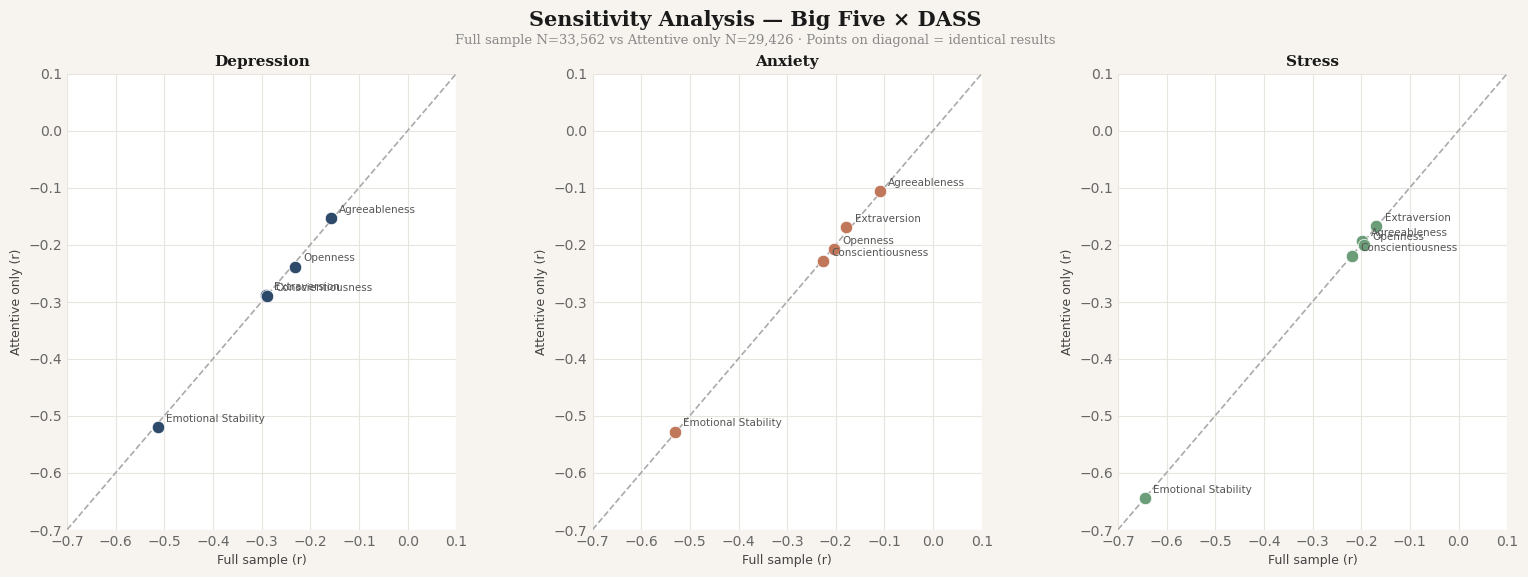

In [51]:
# Sensitivity Analysis (Attentive Sample Only)


df_attentive = df_clean[df_clean['inattentive'] == 0].copy()
n_attentive  = len(df_attentive)
n_removed    = len(df_clean) - n_attentive

print(f"Full sample:      N={len(df_clean):,}")
print(f"Attentive only:   N={n_attentive:,}")
print(f"Removed:          N={n_removed:,} ({n_removed/len(df_clean)*100:.1f}%)")

# ── 1. Big Five × DASS — full vs attentive ────────────────────────────────────
big_five  = ['extraversion', 'agreeableness', 'conscientiousness',
             'emotional_stability', 'openness']
subscales = ['depression', 'anxiety', 'stress']
bf_labels = ['Extraversion', 'Agreeableness', 'Conscientiousness',
             'Emotional Stability', 'Openness']
ss_labels = ['Depression', 'Anxiety', 'Stress']

print(f"\n{'─'*65}")
print("Big Five × DASS — Full sample vs Attentive only")
print(f"{'─'*65}")
print(f"{'':22} {'Full r':>8} {'Att. r':>8} {'Diff':>8}")
print(f"{'─'*65}")

for trait, label in zip(big_five, bf_labels):
    for subscale, ss_label in zip(subscales, ss_labels):
        r_full, _ = pearsonr(df_clean[trait],     df_clean[subscale])
        r_att,  _ = pearsonr(df_attentive[trait], df_attentive[subscale])
        diff = r_att - r_full
        print(f"{label:22} × {ss_label:12} {r_full:>8.3f} {r_att:>8.3f} {diff:>+8.3f}")
    print()

# ── 2. Gender × DASS — full vs attentive ─────────────────────────────────────
print(f"{'─'*65}")
print("Gender × DASS — Full sample vs Attentive only")
print(f"{'─'*65}")

gender_order = ['Male', 'Female', 'Other']

for subscale, ss_label in zip(subscales, ss_labels):
    # Full sample
    groups_full = [df_clean[df_clean['gender_label'] == g][subscale]
                   for g in gender_order]
    F_full, p_full = stats.f_oneway(*groups_full)

    # Attentive only
    groups_att = [df_attentive[df_attentive['gender_label'] == g][subscale]
                  for g in gender_order]
    F_att, p_att = stats.f_oneway(*groups_att)

    print(f"{ss_label:12} Full: F={F_full:.2f}, p<.001 | "
          f"Attentive: F={F_att:.2f}, p<.001")

# ── 3. Education × DASS — full vs attentive ───────────────────────────────────
print(f"\n{'─'*65}")
print("Education × DASS — Full sample vs Attentive only")
print(f"{'─'*65}")

edu_order = ['Less than\nhigh school', 'High school', 'University', 'Graduate']

for subscale, ss_label in zip(subscales, ss_labels):
    groups_full = [df_clean[df_clean['education_label'] == g][subscale]
                   for g in edu_order]
    F_full, p_full = stats.f_oneway(*groups_full)

    groups_att = [df_attentive[df_attentive['education_label'] == g][subscale]
                  for g in edu_order]
    F_att, p_att = stats.f_oneway(*groups_att)

    print(f"{ss_label:12} Full: F={F_full:.2f} | Attentive: F={F_att:.2f}")

# ── Visualization: scatter of full vs attentive Big Five correlations ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

colors = ['#2D4A6B', '#C1775A', '#6B9E78']

for ax, subscale, ss_label, color in zip(axes, subscales, ss_labels, colors):
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#666666', length=0)
    ax.grid(color='#E8E4DE', linewidth=0.8, zorder=0)

    r_full_vals = [pearsonr(df_clean[t],     df_clean[subscale])[0]
                   for t in big_five]
    r_att_vals  = [pearsonr(df_attentive[t], df_attentive[subscale])[0]
                   for t in big_five]

    ax.scatter(r_full_vals, r_att_vals,
               color=color, s=80, zorder=3,
               edgecolors='white', linewidth=0.5)

    # Label each dot with trait name
    for x, y, label in zip(r_full_vals, r_att_vals, bf_labels):
        ax.annotate(label, (x, y),
                    textcoords='offset points',
                    xytext=(6, 4),
                    fontsize=7.5, color='#555555')

    # Identity line (perfect agreement)
    lims = [-0.7, 0.1]
    ax.plot(lims, lims, color='#AAAAAA',
            linestyle='--', linewidth=1.2, zorder=2)

    ax.set_xlim(-0.7, 0.1)
    ax.set_ylim(-0.7, 0.1)
    ax.set_xlabel('Full sample (r)', fontsize=9, color='#444444')
    ax.set_ylabel('Attentive only (r)', fontsize=9, color='#444444')
    ax.set_title(ss_label, fontsize=11, fontweight='bold',
                 color='#1a1a1a', fontfamily='serif')

fig.text(0.5, 0.96, 'Sensitivity Analysis — Big Five × DASS',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93,
         f'Full sample N={len(df_clean):,} vs Attentive only N={n_attentive:,} · '
         f'Points on diagonal = identical results',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

In [52]:
# Quick check: severe depression prevalence before logistic regression

severe = (df_clean['depression'] >= 21).sum()
print(f"Severe depression: {severe:,} ({severe/len(df_clean)*100:.1f}%)")

Severe depression: 16,537 (49.3%)


Note that the 49% base rate of severe depression reflects the online, self-selected 
nature of the sample rather than clinical prevalence. Participants on 
openpsychometrics.org likely skew toward higher distress levels.

## Logistic Regression — Predicting Severe Depression

To identify the strongest predictors of clinically significant depression, a logistic
regression model was built to predict severe depression (DASS-42 score ≥21, corresponding
to the 'Severe' threshold per Lovibond & Lovibond, 1995). Predictors included Big Five
traits, demographic variables, and socioeconomic indicators. Model robustness was tested
by comparing results across the full sample and the attentive-only subsample.

N for logistic regression: 30,156
Severe depression: 14,940 (49.5%)

Features after encoding: 24
Feature names:
['age', 'familysize', 'extraversion', 'agreeableness', 'conscientiousness', 'emotional_stability', 'openness', 'gender_label_Male', 'gender_label_Other', 'education_label_High school', 'education_label_Less than\nhigh school', 'education_label_University', 'region_Southeast Asian', 'region_Western', 'marital_label_Never\nmarried', 'marital_label_Previously\nmarried', 'religion_label_Atheist', 'religion_label_Christian', 'religion_label_Muslim', 'religion_label_Other', 'orientation_label_Bisexual', 'orientation_label_Heterosexual', 'orientation_label_Homosexual', 'orientation_label_Other']

Training set: 24,124
Test set:     6,032

──────────────────────────────────────────────────
Model Performance — Test Set
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Severe       0.72      0.69      0.70      3044
      Sev

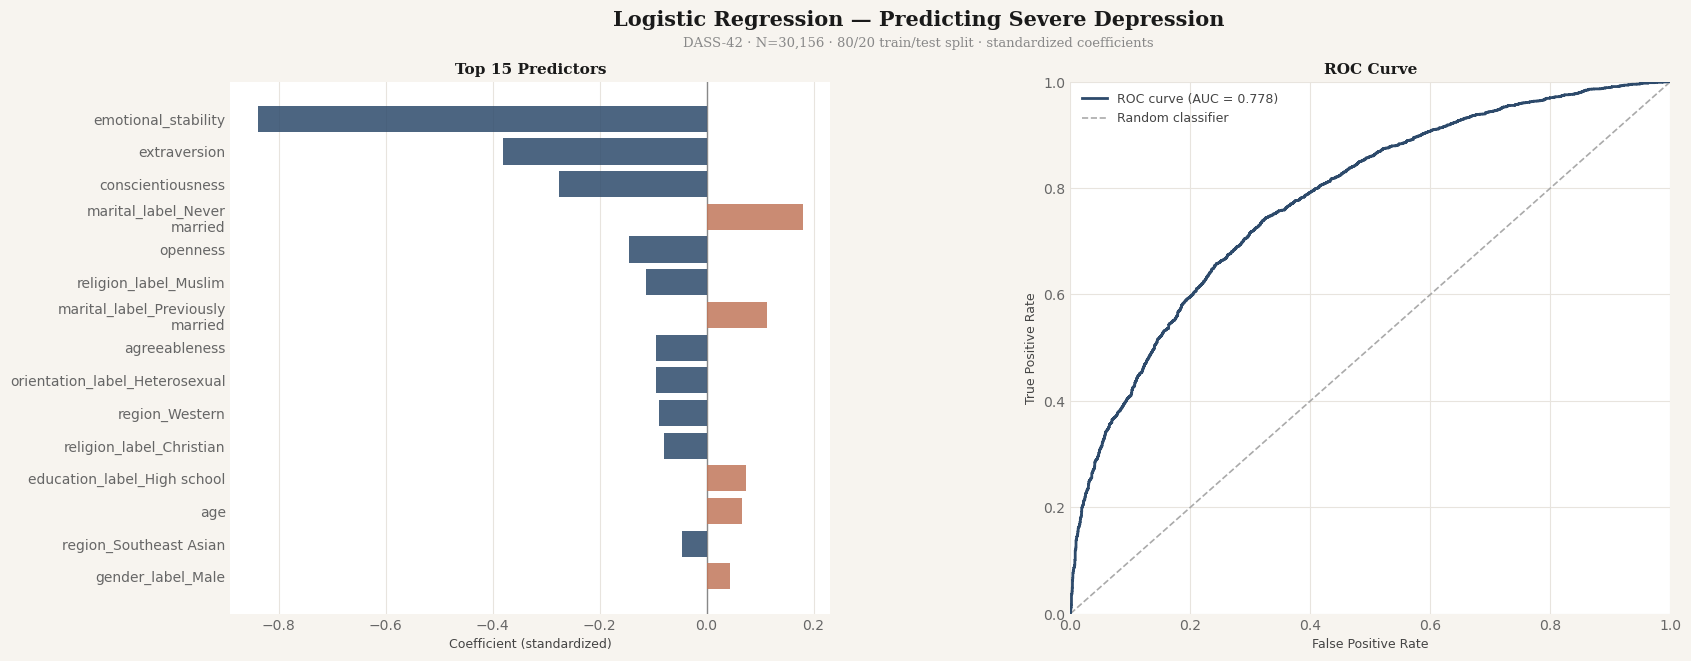

In [53]:
#  Logistic Regression: Predicting Severe Depression


warnings.filterwarnings('ignore')

# --- Create outcome variable ---
df_clean['severe_depression'] = (df_clean['depression'] >= 21).astype(int)

# --- Prepare dataset ---
# Apply all filters: valid orientation + valid religion
df_lr = df_clean[
    (df_clean['orientation_missing'] == 0) &
    (df_clean['religion_label'].isin(['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other']))
].copy()

print(f"N for logistic regression: {len(df_lr):,}")
print(f"Severe depression: {df_lr['severe_depression'].sum():,} ({df_lr['severe_depression'].mean()*100:.1f}%)")

# --- Dummy coding categorical variables ---
# pd.get_dummies converts categorical columns into binary columns
# drop_first=True drops one category per variable to avoid multicollinearity
df_encoded = pd.get_dummies(df_lr[[
    'severe_depression',
    'age', 'familysize',
    'extraversion', 'agreeableness', 'conscientiousness',
    'emotional_stability', 'openness',
    'gender_label', 'education_label', 'region',
    'marital_label', 'religion_label', 'orientation_label'
]], columns=[
    'gender_label', 'education_label', 'region',
    'marital_label', 'religion_label', 'orientation_label'
], drop_first=True)

print(f"\nFeatures after encoding: {df_encoded.shape[1] - 1}")
print(f"Feature names:\n{[c for c in df_encoded.columns if c != 'severe_depression']}")

# --- Split features and outcome ---
X = df_encoded.drop('severe_depression', axis=1)
y = df_encoded['severe_depression']

# --- Train/test split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set: {len(X_train):,}")
print(f"Test set:     {len(X_test):,}")

# --- Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Fit logistic regression ---
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# --- Evaluate on test set ---
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"\n{'─'*50}")
print("Model Performance — Test Set")
print(f"{'─'*50}")
print(classification_report(y_test, y_pred,
                             target_names=['Not Severe', 'Severe']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.3f}")

# --- Feature importance (coefficients) ---
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\n{'─'*50}")
print("Top 15 Predictors (by absolute coefficient)")
print(f"{'─'*50}")
print(coef_df.head(15).to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.4, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

# Panel 1: Feature importance
ax = axes[0]
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(axis='x', color='#E8E4DE', linewidth=0.8, zorder=0)

top15    = coef_df.head(15)
bar_colors = ['#C1775A' if c > 0 else '#2D4A6B'
              for c in top15['coefficient']]

ax.barh(top15['feature'], top15['coefficient'],
        color=bar_colors, edgecolor='none',
        alpha=0.85, zorder=3)
ax.axvline(0, color='#888888', linewidth=1, zorder=2)
ax.set_xlabel('Coefficient (standardized)', fontsize=9, color='#444444')
ax.set_title('Top 15 Predictors', fontsize=11, fontweight='bold',
             color='#1a1a1a', fontfamily='serif')
ax.invert_yaxis()

# Panel 2: ROC curve
ax = axes[1]
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(color='#E8E4DE', linewidth=0.8, zorder=0)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

ax.plot(fpr, tpr, color='#2D4A6B', linewidth=2,
        label=f'ROC curve (AUC = {auc_score:.3f})', zorder=3)
ax.plot([0, 1], [0, 1], color='#AAAAAA', linewidth=1.2,
        linestyle='--', zorder=2, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=9, color='#444444')
ax.set_ylabel('True Positive Rate', fontsize=9, color='#444444')
ax.set_title('ROC Curve', fontsize=11, fontweight='bold',
             color='#1a1a1a', fontfamily='serif')
ax.legend(fontsize=9, frameon=False, labelcolor='#444444')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.text(0.5, 0.96, 'Logistic Regression — Predicting Severe Depression',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93, f'DASS-42 · N={len(df_lr):,} · 80/20 train/test split · standardized coefficients',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()

Full sample:    N=30,156
Attentive only: N=26,352

──────────────────────────────────────────────────
Full sample (N=30,156)
──────────────────────────────────────────────────
Accuracy: 0.707
AUC:      0.778

Top 10 predictors:
                          feature  coefficient
              emotional_stability    -0.838896
                     extraversion    -0.379986
                conscientiousness    -0.276127
     marital_label_Never\nmarried     0.180561
                         openness    -0.145151
            religion_label_Muslim    -0.113817
marital_label_Previously\nmarried     0.113771
                    agreeableness    -0.095099
   orientation_label_Heterosexual    -0.093809
                   region_Western    -0.089223

──────────────────────────────────────────────────
Attentive only (N=26,352)
──────────────────────────────────────────────────
Accuracy: 0.710
AUC:      0.781

Top 10 predictors:
                          feature  coefficient
              emotional_sta

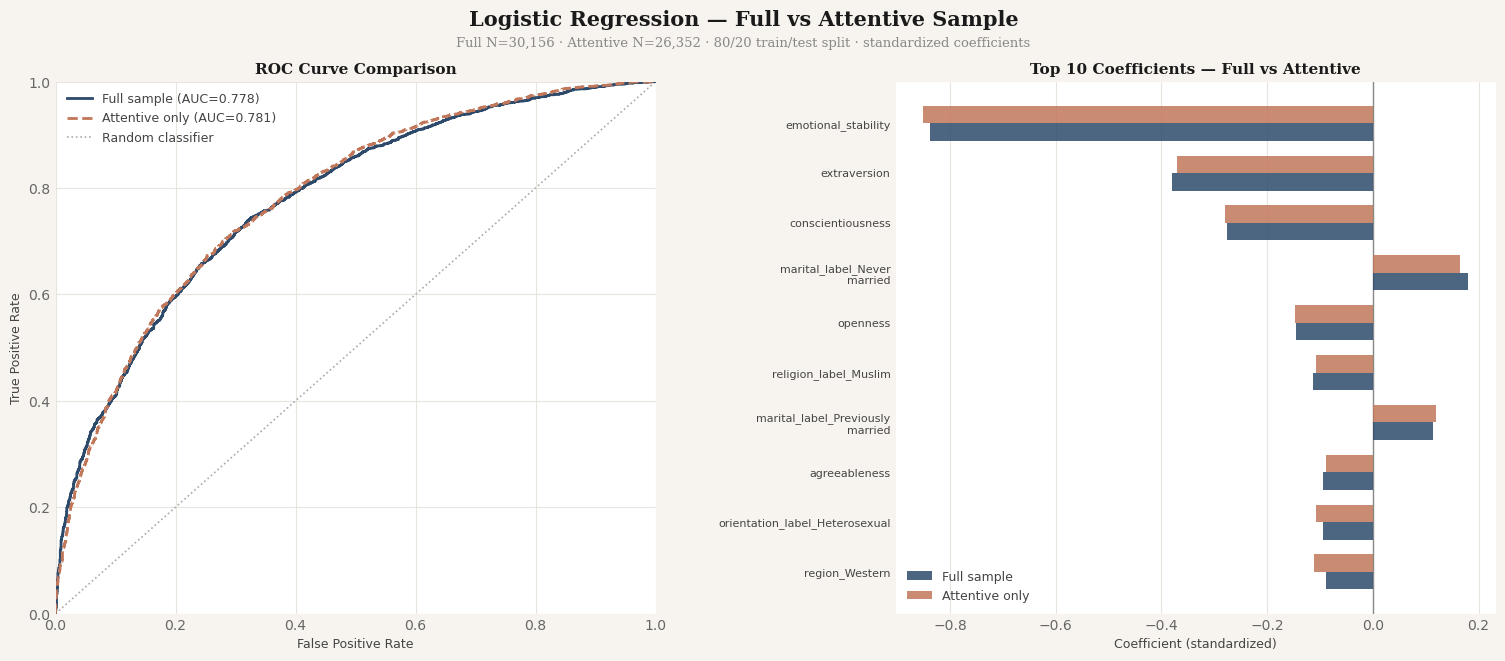

In [54]:
# Logistic Regression: Full vs Attentive Sample 


# --- Prepare attentive-only dataset with same filters ---
df_lr_att = df_attentive[
    (df_attentive['orientation_missing'] == 0) &
    (df_attentive['religion_label'].isin(['Christian', 'Agnostic', 'Atheist', 'Muslim', 'Other']))
].copy()

print(f"Full sample:    N={len(df_lr):,}")
print(f"Attentive only: N={len(df_lr_att):,}")

# --- Function to run full pipeline ---
def run_logistic(df, label):
    df = df.copy()
    df['severe_depression'] = (df['depression'] >= 21).astype(int)

    df_encoded = pd.get_dummies(df[[
        'severe_depression',
        'age', 'familysize',
        'extraversion', 'agreeableness', 'conscientiousness',
        'emotional_stability', 'openness',
        'gender_label', 'education_label', 'region',
        'marital_label', 'religion_label', 'orientation_label'
    ]], columns=[
        'gender_label', 'education_label', 'region',
        'marital_label', 'religion_label', 'orientation_label'
    ], drop_first=True)

    X = df_encoded.drop('severe_depression', axis=1)
    y = df_encoded['severe_depression']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_s, y_train)

    y_pred      = model.predict(X_test_s)
    y_pred_prob = model.predict_proba(X_test_s)[:, 1]

    auc      = roc_auc_score(y_test, y_pred_prob)
    accuracy = (y_pred == y_test).mean()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    coef_df = pd.DataFrame({
        'feature':     X.columns,
        'coefficient': model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)

    print(f"\n{'─'*50}")
    print(f"{label} (N={len(df):,})")
    print(f"{'─'*50}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"AUC:      {auc:.3f}")
    print(f"\nTop 10 predictors:")
    print(coef_df.head(10).to_string(index=False))

    return coef_df, auc, fpr, tpr

# --- Run both models ---
coef_full, auc_full, fpr_full, tpr_full = run_logistic(df_lr,     'Full sample')
coef_att,  auc_att,  fpr_att,  tpr_att  = run_logistic(df_lr_att, 'Attentive only')

# --- Visualization: ROC curves + coefficient comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#F7F4EF')
fig.subplots_adjust(wspace=0.4, top=0.88, bottom=0.12,
                    left=0.07, right=0.97)

# Panel 1: ROC curves overlaid
ax = axes[0]
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(color='#E8E4DE', linewidth=0.8, zorder=0)

ax.plot(fpr_full, tpr_full, color='#2D4A6B', linewidth=2,
        label=f'Full sample (AUC={auc_full:.3f})', zorder=3)
ax.plot(fpr_att,  tpr_att,  color='#C1775A', linewidth=2,
        linestyle='--',
        label=f'Attentive only (AUC={auc_att:.3f})', zorder=3)
ax.plot([0, 1], [0, 1], color='#AAAAAA', linewidth=1.2,
        linestyle=':', zorder=2, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=9, color='#444444')
ax.set_ylabel('True Positive Rate', fontsize=9, color='#444444')
ax.set_title('ROC Curve Comparison', fontsize=11, fontweight='bold',
             color='#1a1a1a', fontfamily='serif')
ax.legend(fontsize=9, frameon=False, labelcolor='#444444')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Panel 2: Top 10 coefficients side by side
ax = axes[1]
ax.set_facecolor('#FFFFFF')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#666666', length=0)
ax.grid(axis='x', color='#E8E4DE', linewidth=0.8, zorder=0)

top10_features = coef_full.head(10)['feature'].tolist()
coef_full_vals = coef_full.set_index('feature').loc[top10_features, 'coefficient']
coef_att_vals  = coef_att.set_index('feature').reindex(top10_features)['coefficient']

x      = range(len(top10_features))
width  = 0.35

ax.barh([xi + width/2 for xi in x], coef_full_vals,
        height=width, color='#2D4A6B', alpha=0.85,
        edgecolor='none', zorder=3, label='Full sample')
ax.barh([xi - width/2 for xi in x], coef_att_vals,
        height=width, color='#C1775A', alpha=0.85,
        edgecolor='none', zorder=3, label='Attentive only')

ax.set_yticks(list(x))
ax.set_yticklabels(top10_features, fontsize=8, color='#444444')
ax.axvline(0, color='#888888', linewidth=1, zorder=2)
ax.invert_yaxis()
ax.set_xlabel('Coefficient (standardized)', fontsize=9, color='#444444')
ax.set_title('Top 10 Coefficients — Full vs Attentive',
             fontsize=11, fontweight='bold',
             color='#1a1a1a', fontfamily='serif')
ax.legend(fontsize=9, frameon=False, labelcolor='#444444')

fig.text(0.5, 0.96, 'Logistic Regression — Full vs Attentive Sample',
         ha='center', fontsize=15, fontweight='bold',
         color='#1a1a1a', fontfamily='serif')
fig.text(0.5, 0.93,
         f'Full N={len(df_lr):,} · Attentive N={len(df_lr_att):,} · '
         f'80/20 train/test split · standardized coefficients',
         ha='center', fontsize=9.5, color='#888888', fontfamily='serif')

plt.show()